# 2026-08-31 Pre-peak SF, Balmer non-detection, and non-SF fractions

Copied from `20260828_check_SF_fraction_pre_peak.ipynb`. The pre-peak sample,
inclination cut ($i<80^\circ$), valid-disc denominator, geometry (including the
minimum component $R/R_e$ for NGC4567_8), bins, and original SF selection are unchanged.
The original mass-radius and stellar-mass-map diagnostics are retained.

Let $V$ be the original valid-disc mask, $S$ the original SF mask, and
$D_{\rm B}=D_{\mathrm{H}\alpha}\cap D_{\mathrm{H}\beta}$ the mask where **both
Halpha and Hbeta pass detection**. For every bin, use the same $N_V$ denominator:

$$f_{\rm SF}=N(S)/N_V,\qquad
f_{\rm ND}=N(V\cap\neg D_{\rm B})/N_V,\qquad
f_{\rm NSF}=N(V\cap D_{\rm B}\cap\neg S)/N_V.$$

**ND means Halpha or Hbeta (or both) fails detection.** Weak [O III], [N II],
or [S II] lines do not assign a pixel to ND. The inherited SF selection already
requires both Balmer detections, and this notebook checks $S\subseteq D_{\rm B}$
for every included product. The three categories are therefore disjoint and sum
to one. Fractions are shown only for $N_V\ge50$.

SF remains exactly the original selection: finite `LOGSFR_SURFACE_DENSITY_HII`,
EW(Halpha)>6 Angstrom, and finite intrinsic Halpha dispersion <45 km/s.
Requiring Balmer detections again would give the same SF mask, so no additional
detected-SF fraction is defined or plotted. This does **not** impose a six-line
detection requirement on SF.

NSF means **both Balmer lines detected, but not selected as SF**; it does not
require detection of every forbidden line and does not prove absence of star
formation. It can include weak or ambiguous BPT diagnostics, low EW, high
dispersion, and unavailable ancillary measurements. These are exposed below.
The original `_HII` products and the stricter independent `NII_BPT`/`SII_BPT`
class maps have different acceptance rules. The class maps are used only to
describe rejected pixels; they never replace the original SF selection.

For each Balmer line, detection requires finite raw flux and positive finite raw
flux error, with $F/\sigma_F\ge\mathtt{CUT\_SN}$ and
$F\ge\mathtt{NOISE}$ from that gas FITS primary header. The current products
use 3 and 20 respectively; the latter is in
$10^{-20}\,{\rm erg\,s^{-1}\,cm^{-2}}$ per map pixel. These are the thresholds
in `SFR+Z.py::apply_QC`. Failing the flux floor need not imply low S/N.
Missing/invalid Balmer flux or error also prevents establishing detection and
is counted separately within ND. BPT classifications use the stored products
based on **dust-corrected** fluxes, with no new BPT or upper-limit inference here.

The valid footprint requires finite stellar density, finite gas BIN_ID, MASK==0,
and finite radius. No extra inclination correction is applied. These fractions
describe selection outcomes within that footprint, not excluded/unobserved
pixels or a physical cause of quenching.


## 1. Configuration and imports

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_EDGES = np.linspace(6.0, 10.0, 13)
R_EDGES = np.arange(0.0, 1.6 + 0.2, 0.2)
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: pre-peak, science-ready primary sample with inclination < 80 deg")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: pre-peak, science-ready primary sample with inclination < 80 deg
No additional inclination correction is applied to either surface-density map.


## 2. Reusable data and measurement helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {a.shape for a in (mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr)}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps


def binned_categories(values, maps, edges):
    result = binned_fraction(values, maps["valid_disc_mask"], maps["sf_mask"], edges)
    for label, key in (("ND", "nd_mask"), ("NSF", "nsf_mask")):
        extra = binned_fraction(values, maps["valid_disc_mask"], maps[key], edges)
        result["N_" + label] = extra.N_SF
        result["f_" + label] = extra.f_SF
    assert np.array_equal(result.N_SF + result.N_ND + result.N_NSF, result.N_valid)
    shown = result.N_valid >= MIN_VALID_PIXELS_PER_BIN
    assert np.allclose(result.loc[shown, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1)
    assert int(result.N_valid.sum()) == int(maps["valid_disc_mask"].sum())
    return result


def plot_category_fractions(axis, table):
    for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
        axis.plot(table.center, table["f_" + label], marker="o", ms=3, lw=1.8,
                  ls=linestyle, color=CATEGORY_COLORS[label], label=r"$f_{\rm " + label + "}$")
    axis.legend(fontsize=8, ncol=3, loc="best")


## 3. Live pre-peak inventory and QC

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir() if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS]),
            "ew_path": first_existing([folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
        })
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one"
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
prepeak_candidates = inventory.loc[
    inventory.stage.eq("pre-peak") & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values("GALID").reset_index(drop=True)

map_cache = {}
qc_rows = []
for row in prepeak_candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path), ("ew", row.ew_path), ("mask", row.mask_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            if np.any(maps["sf_mask"] & ~maps["valid_disc_mask"]):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        map_cache[row.GALID] = maps
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid_stellar_pixels": int(maps["valid_disc_mask"].sum()) if maps is not None else 0,
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()) if maps is not None else 0,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

PREPEAK_QC = pd.DataFrame(qc_rows)
prepeak = prepeak_candidates.loc[
    prepeak_candidates.GALID.isin(PREPEAK_QC.loc[PREPEAK_QC.QC_flag.eq("OK"), "GALID"])
].copy()

display(PREPEAK_QC)
print(f"Pre-peak primary products passing QC: {len(prepeak)}/{len(prepeak_candidates)}")
print("Included:", ", ".join(prepeak.GALID))
if len(prepeak) == 0:
    raise RuntimeError("No pre-peak galaxies passed the live product QC")

Pre-peak primary products passing QC: 8/8
Included: NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8


,GALID,components,stage,inclination_deg,N_valid_stellar_pixels,N_selected_SF_pixels,wcs_separation_arcsec,QC_flag
0,NGC4189,NGC4189,pre-peak,42.0,177204,96364,0.0,OK
1,NGC4254,NGC4254,pre-peak,39.0,1043477,661963,0.0,OK
2,NGC4294,NGC4294,pre-peak,74.0,179355,68833,0.0,OK
3,NGC4321,NGC4321,pre-peak,32.0,970159,454131,0.0,OK
4,NGC4351,NGC4351,pre-peak,48.0,180133,30711,0.0,OK
5,NGC4383,NGC4383,pre-peak,56.0,227031,25212,0.0,OK
6,NGC4535,NGC4535,pre-peak,48.0,525101,187113,0.0,OK
7,NGC4567_8,"NGC4567,NGC4568",pre-peak,70.0,510118,222533,0.0,OK


## 4. Three side-by-side diagnostics for each pre-peak galaxy

The first two panels use the same minimum denominator as the source SF-fraction notebook: a bin is shown only with at least 50 valid disc pixels. In the third panel, the all-pixel median requires at least 50 valid pixels and the selected-SF median requires at least 20 SF pixels.

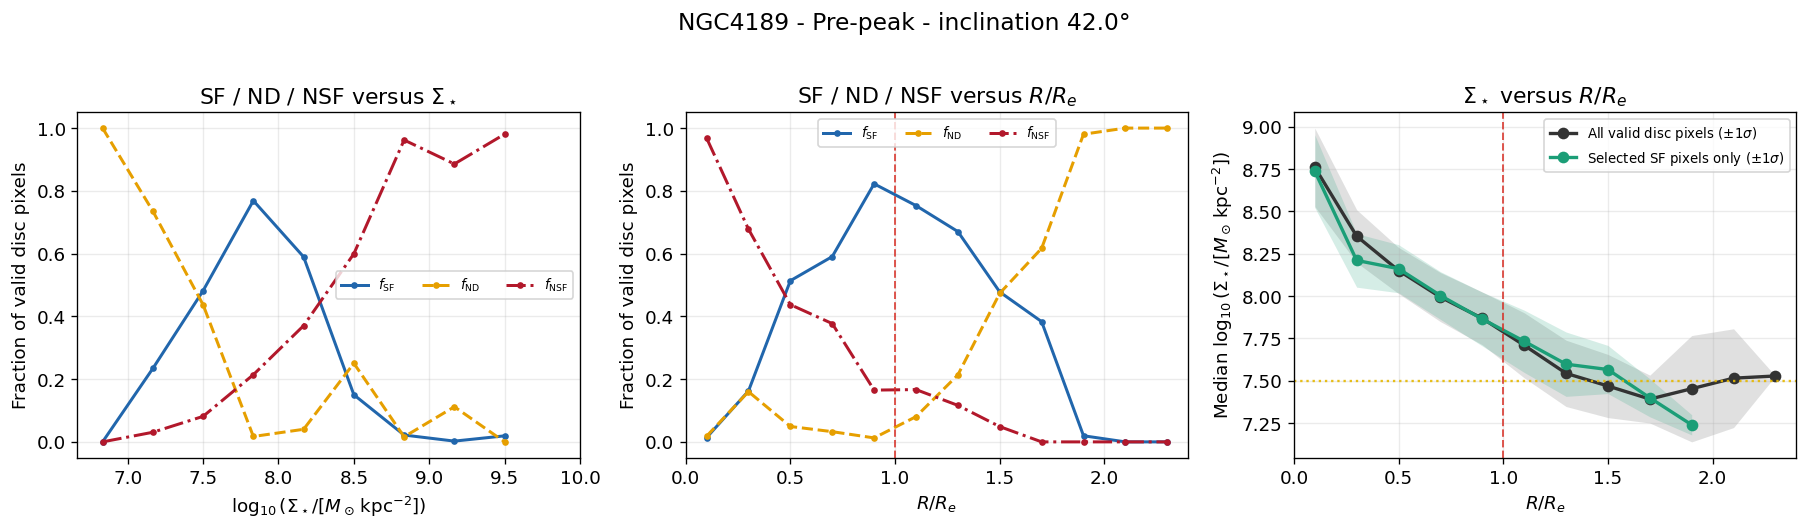

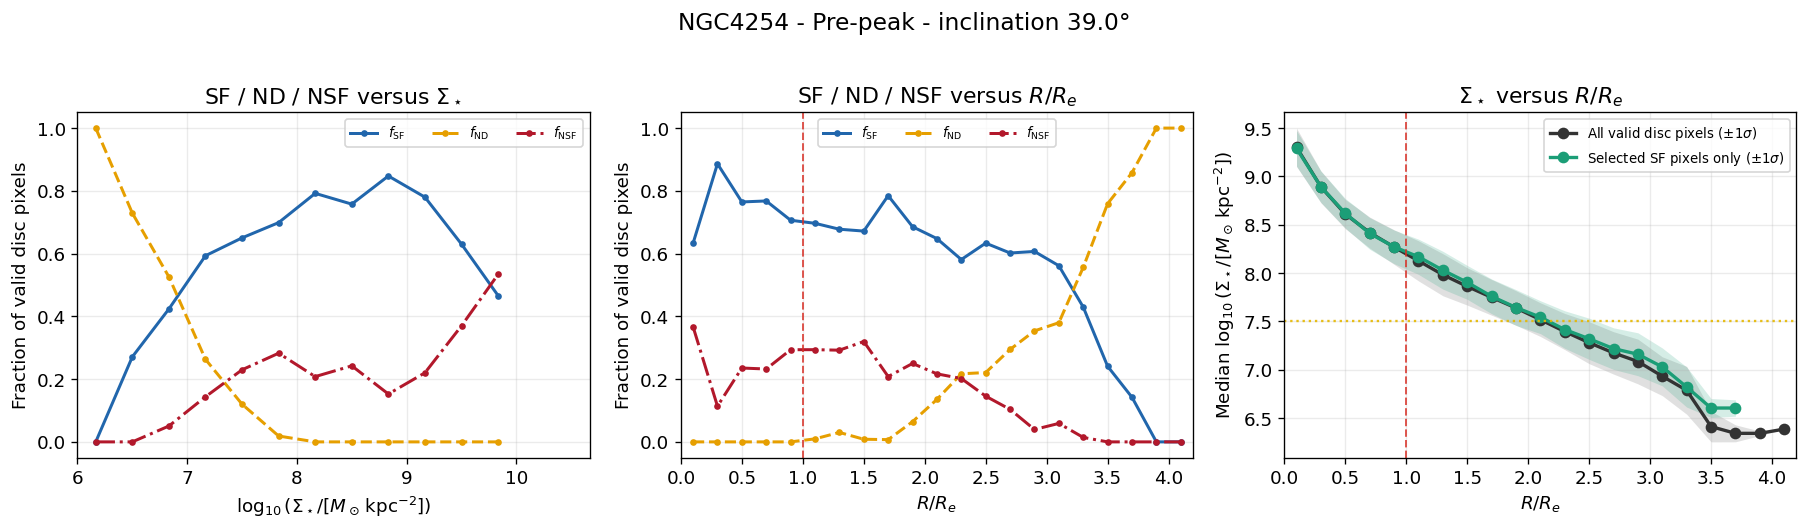

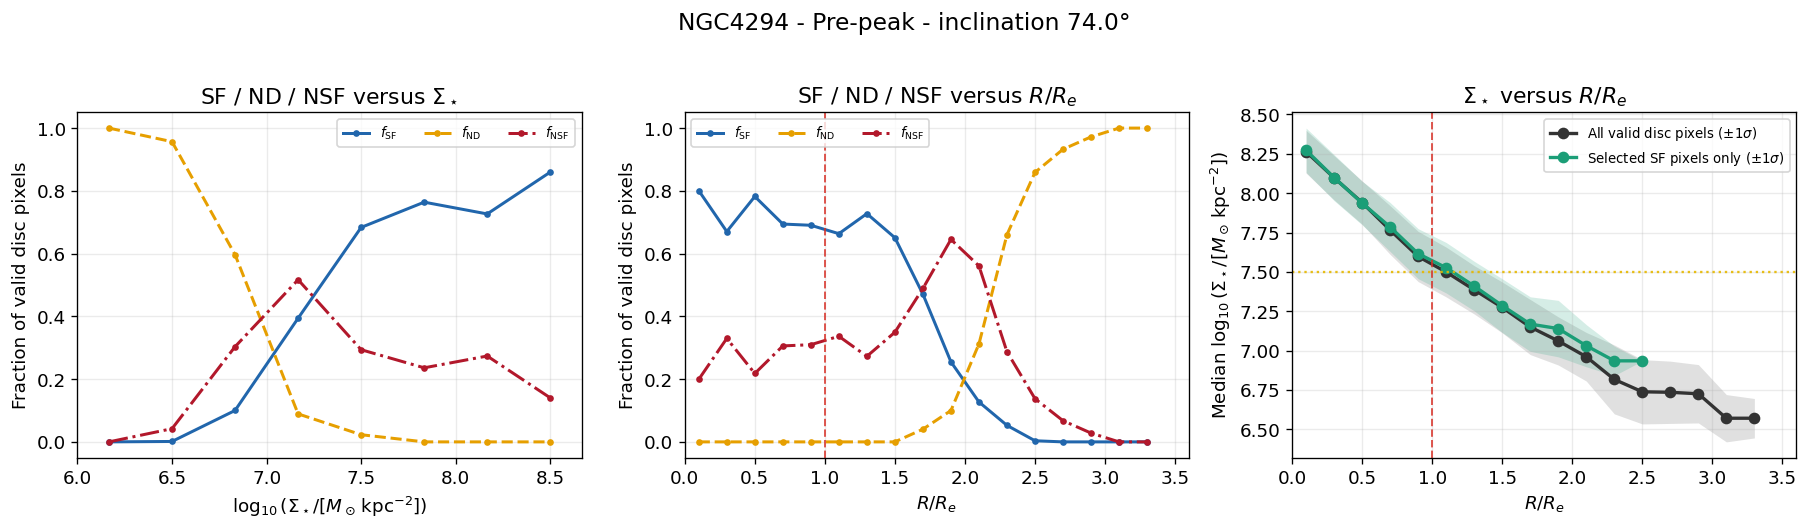

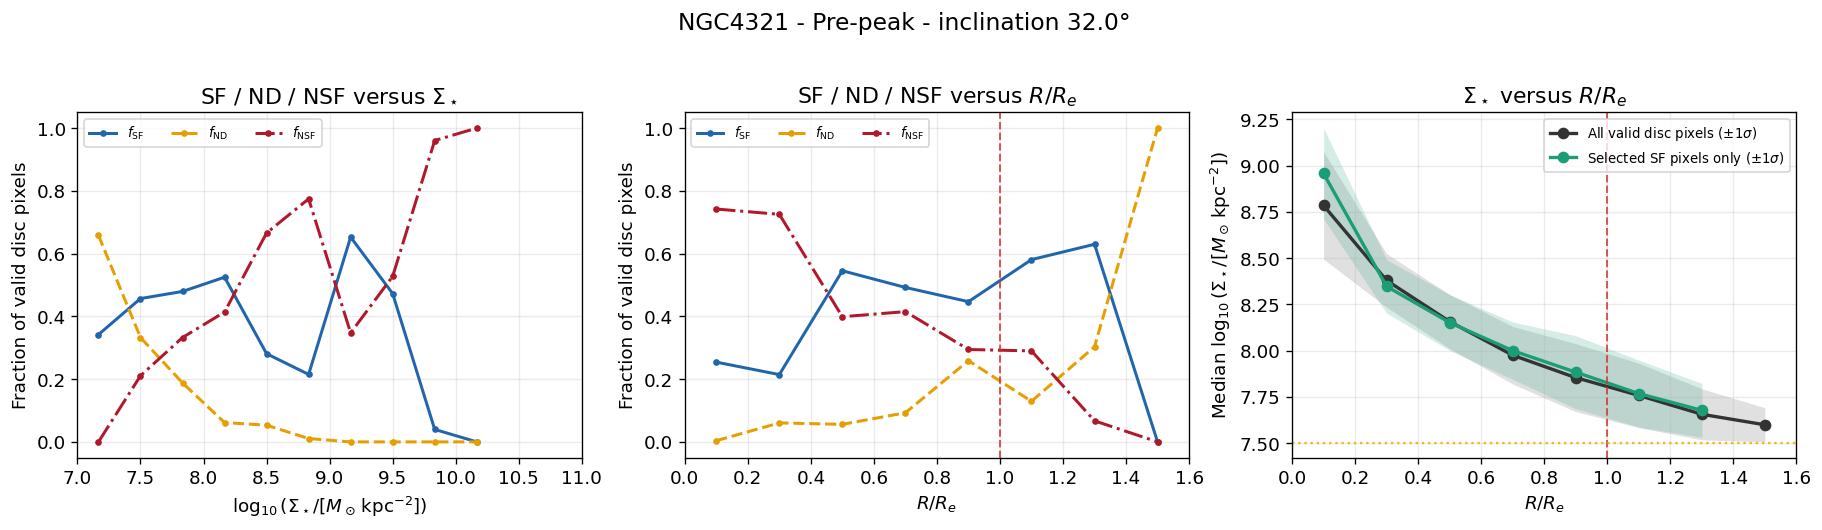

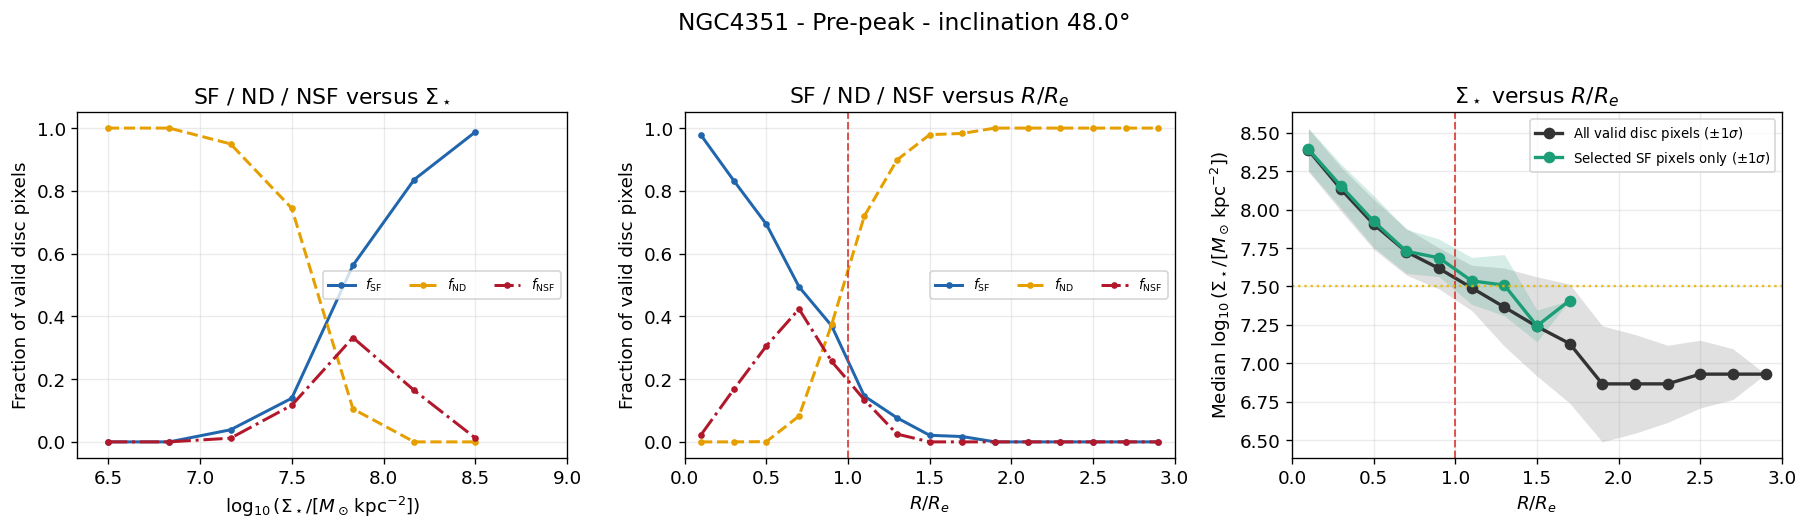

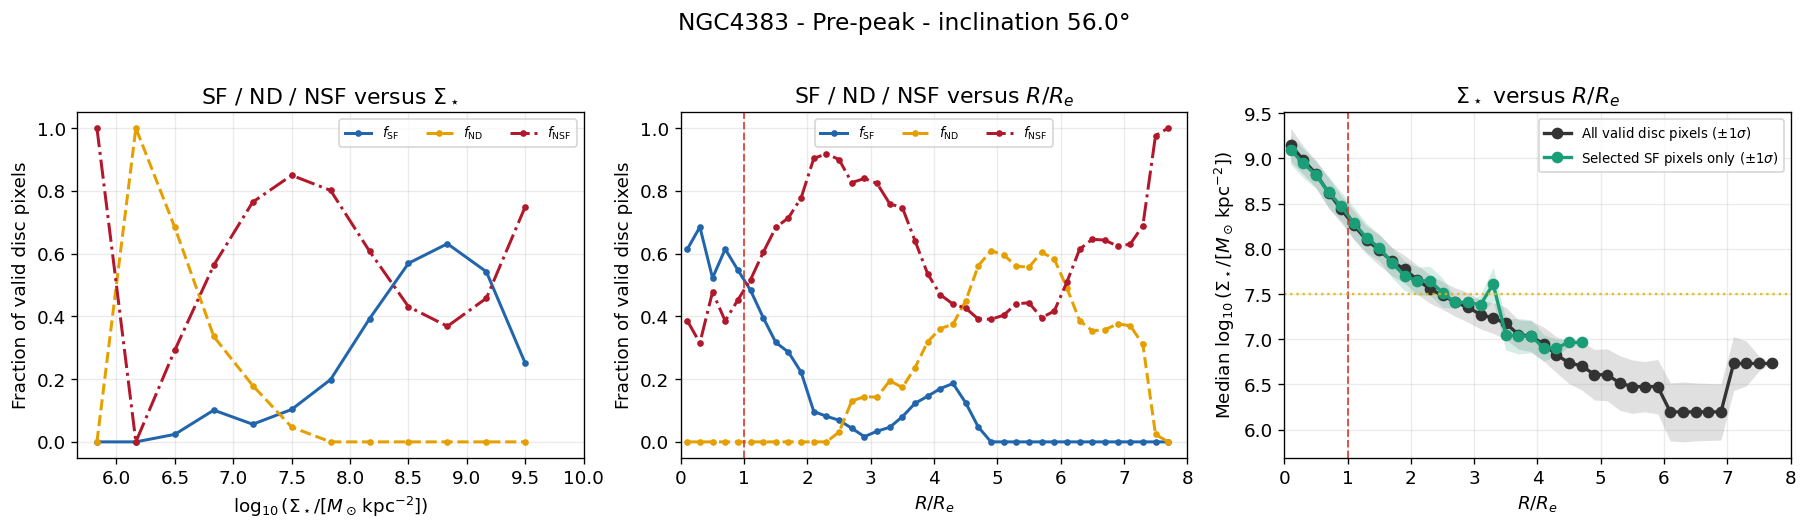

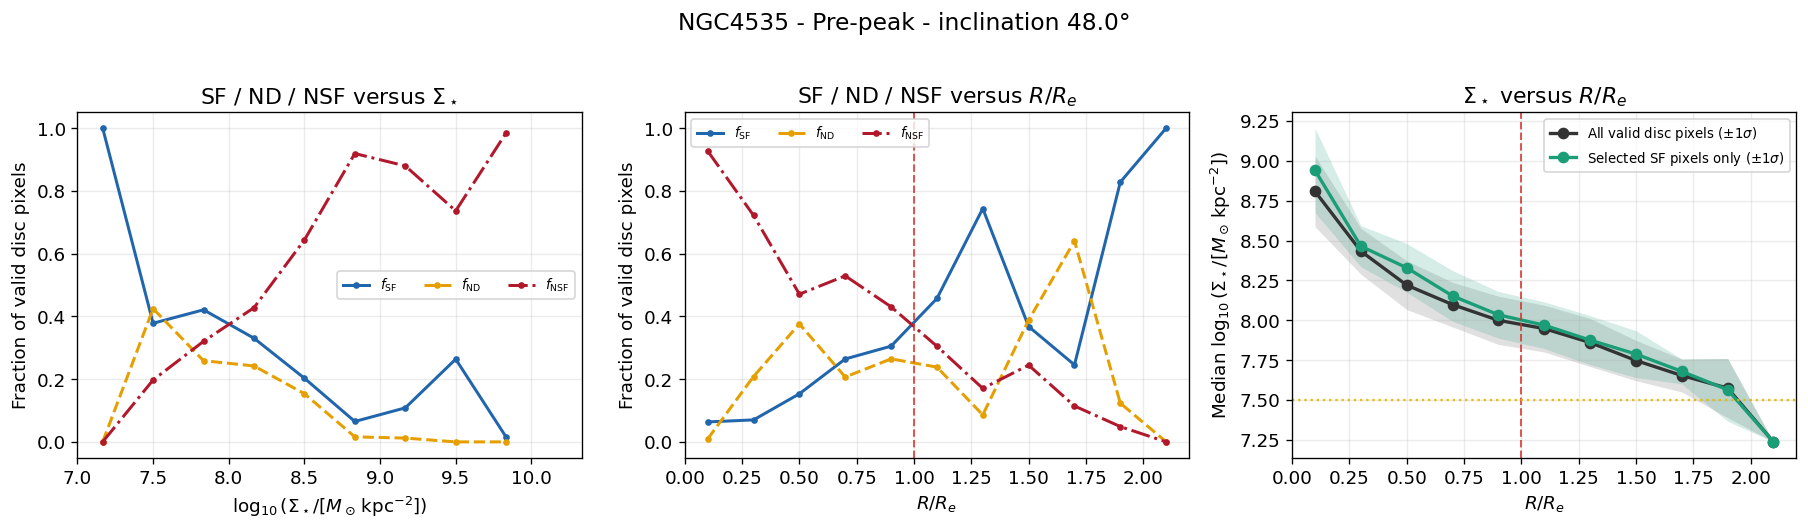

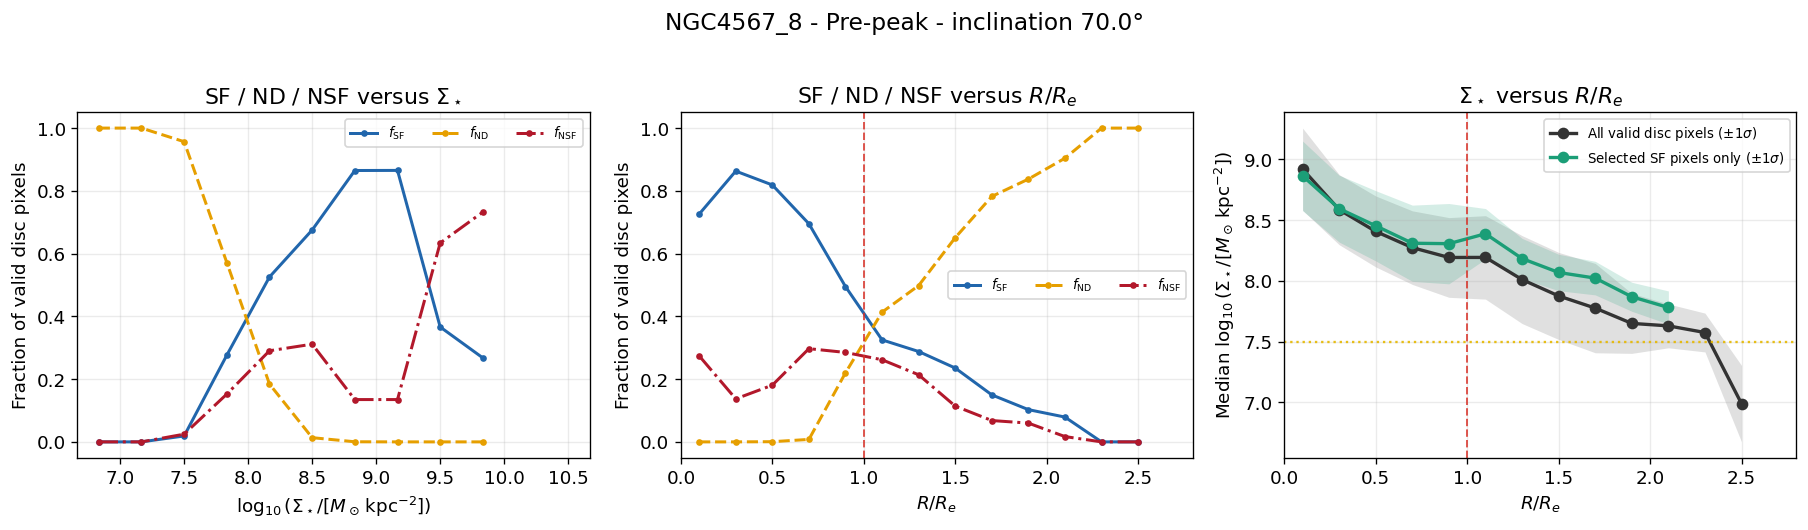

In [4]:
individual_measurements = {}


def complete_bin_edges(values, valid_mask, bin_width, *, lower_limit=None):
    """Return aligned edges that include the full finite range of valid values."""
    finite_values = np.asarray(values, dtype=float)[valid_mask & np.isfinite(values)]
    if finite_values.size == 0:
        raise ValueError("Cannot construct bins from an empty valid range")
    data_min = float(np.nanmin(finite_values))
    data_max = float(np.nanmax(finite_values))
    start = (
        float(lower_limit)
        if lower_limit is not None
        else np.floor(data_min / bin_width) * bin_width
    )
    stop = (np.floor(data_max / bin_width) + 1.0) * bin_width
    return np.arange(start, stop + 0.5 * bin_width, bin_width)


SIGMA_BIN_WIDTH = float(np.median(np.diff(SIGMA_EDGES)))
RADIUS_BIN_WIDTH = float(np.median(np.diff(R_EDGES)))

for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    galaxy_sigma_edges = complete_bin_edges(
        maps["log_sigma_star"], maps["valid_disc_mask"], SIGMA_BIN_WIDTH
    )
    galaxy_radius_edges = complete_bin_edges(
        maps["radius_re"], maps["valid_disc_mask"], RADIUS_BIN_WIDTH, lower_limit=0.0
    )
    by_sigma = binned_categories(
        maps["log_sigma_star"], maps, galaxy_sigma_edges
    )
    by_radius = binned_categories(
        maps["radius_re"], maps, galaxy_radius_edges
    )
    mass_by_radius = radial_mass_trends(maps, galaxy_radius_edges)

    # For the mass-radius panel, calculate the actual scatter in log Sigma_star
    # independently for all valid pixels and for selected SF pixels.
    all_std, sf_std = [], []
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    for lo, hi in zip(galaxy_radius_edges[:-1], galaxy_radius_edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        all_std.append(
            np.nanstd(mass[all_pixels], ddof=1)
            if int(all_pixels.sum()) >= MIN_VALID_PIXELS_PER_BIN else np.nan
        )
        sf_std.append(
            np.nanstd(mass[sf_pixels], ddof=1)
            if int(sf_pixels.sum()) >= MIN_SF_PIXELS_PER_BIN else np.nan
        )
    mass_by_radius["all_std"] = all_std
    mass_by_radius["sf_std"] = sf_std

    individual_measurements[row.GALID] = {
        "fSF_by_sigma": by_sigma,
        "fSF_by_radius": by_radius,
        "mass_by_radius": mass_by_radius,
        "sigma_edges": galaxy_sigma_edges,
        "radius_edges": galaxy_radius_edges,
    }

    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.3))
    fig.suptitle(
        f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f}°",
        fontsize=14, y=1.02,
    )

    plot_category_fractions(axes[0], by_sigma)
    axes[0].set(
        xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $\Sigma_\star$",
        xlim=(galaxy_sigma_edges[0], galaxy_sigma_edges[-1]), ylim=(-0.05, 1.05),
    )
    plot_category_fractions(axes[1], by_radius)
    axes[1].set(
        xlabel=r"$R/R_e$", ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)
    axes[2].fill_between(
        mass_by_radius.radius_center,
        mass_by_radius.all_median - mass_by_radius.all_std,
        mass_by_radius.all_median + mass_by_radius.all_std,
        color="0.2", alpha=0.15, linewidth=0,
    )
    axes[2].fill_between(
        mass_by_radius.radius_center,
        mass_by_radius.sf_median - mass_by_radius.sf_std,
        mass_by_radius.sf_median + mass_by_radius.sf_std,
        color="#1b9e77", alpha=0.18, linewidth=0,
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.all_median,
        marker="o", lw=2.0, color="0.2", label=r"All valid disc pixels ($\pm1\sigma$)",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.sf_median,
        marker="o", lw=2.0, color="#1b9e77", label=r"Selected SF pixels only ($\pm1\sigma$)",
    )
    axes[2].set(
        xlabel=r"$R/R_e$",
        ylabel=r"Median $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        title=r"$\Sigma_\star$ versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]),
    )
    axes[2].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)
    axes[2].axhline(MASS_CONTOUR_LEVEL, color="#e6b800", ls=":", lw=1.4, alpha=0.9)
    axes[2].legend(fontsize=8)

    for axis in axes:
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

### Interpretation guide

- $f_{\rm SF}$ is the fraction of valid disc pixels in the bin that pass the unchanged H II + EW + intrinsic-dispersion SF selection.
- The third panel compares like-for-like radial bins within the same galaxy. A separation between the black and green tracks indicates that the selected SF pixels occupy a different $\Sigma_\star$ distribution from the full valid disc footprint at that radius.
- The dashed vertical line marks $R/R_e=1$; the dotted yellow horizontal guide marks $\log\Sigma_\star=7.5$, matching the contour used below.
- SF (blue), ND (orange), and NSF (red) share the original denominator and sum to one in every supported bin.
- ND means at least one Balmer line fails its detection cut. NSF means both Balmer lines pass but the original SF selection fails; weak forbidden lines, ambiguous classification, or missing ancillary measurements may still be present. Inspect the reason diagnostics before assigning a physical interpretation.


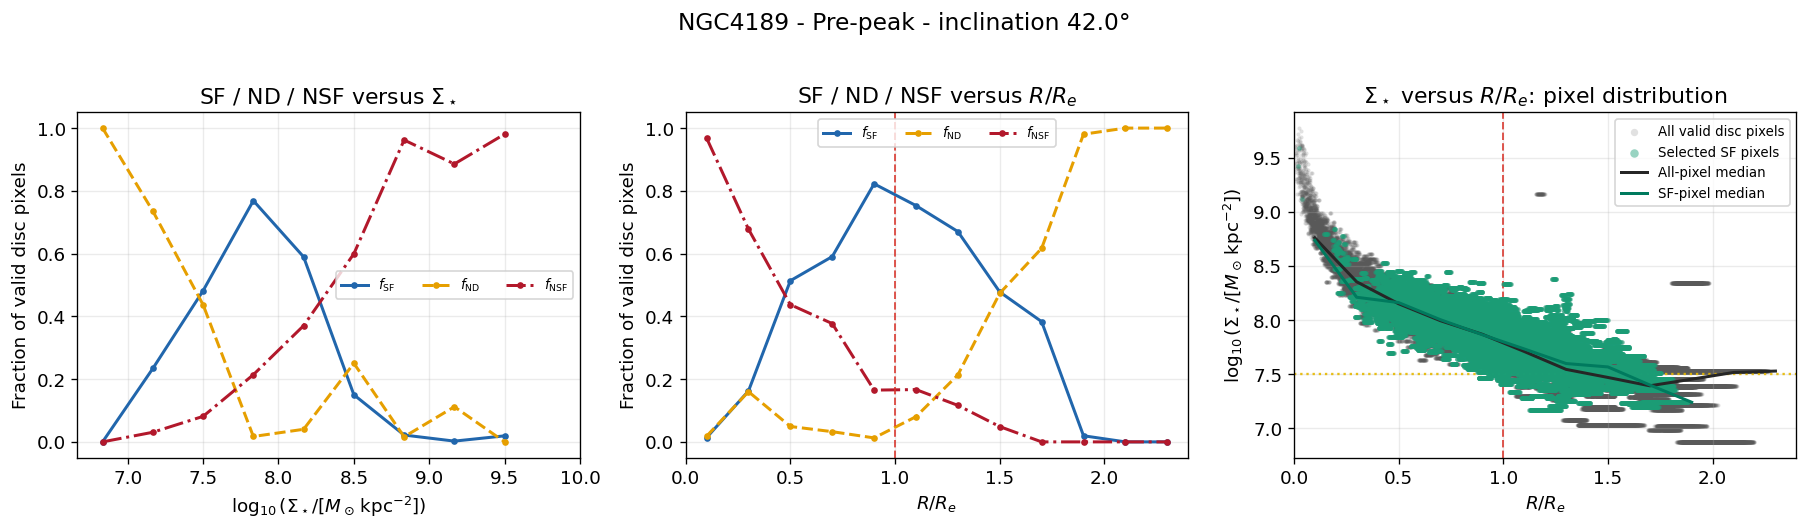

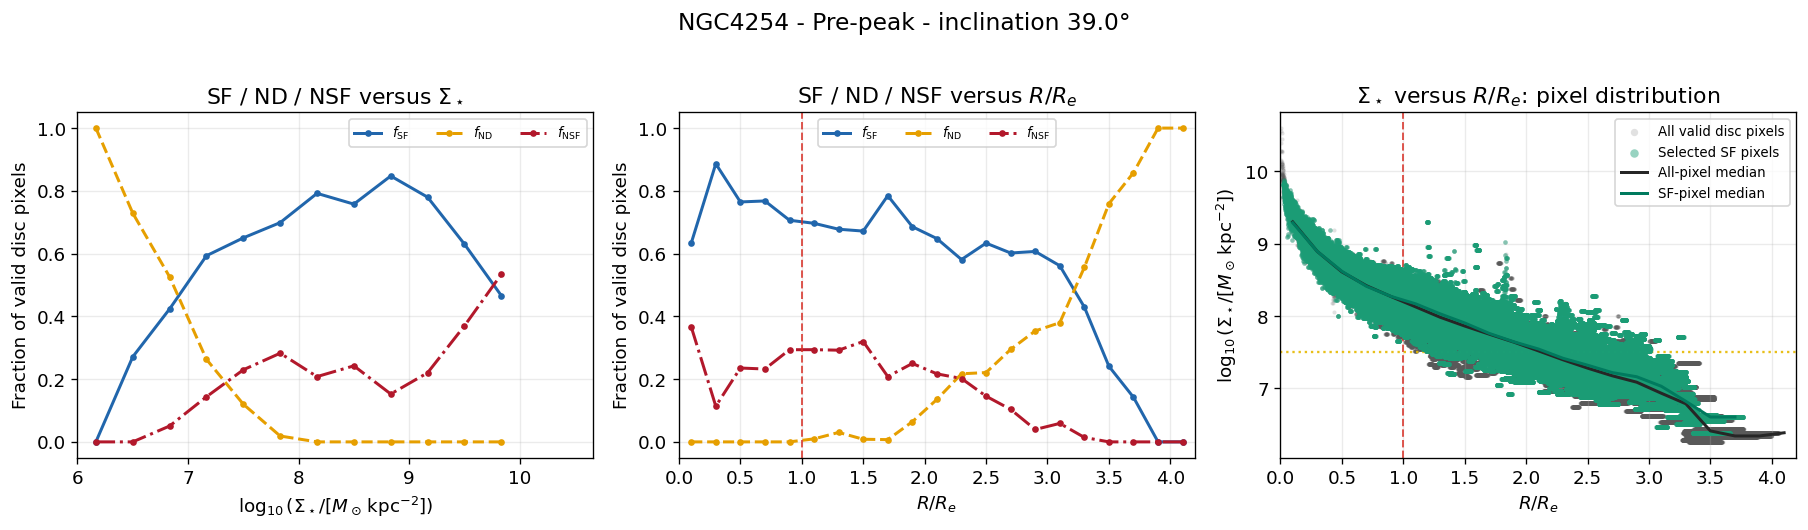

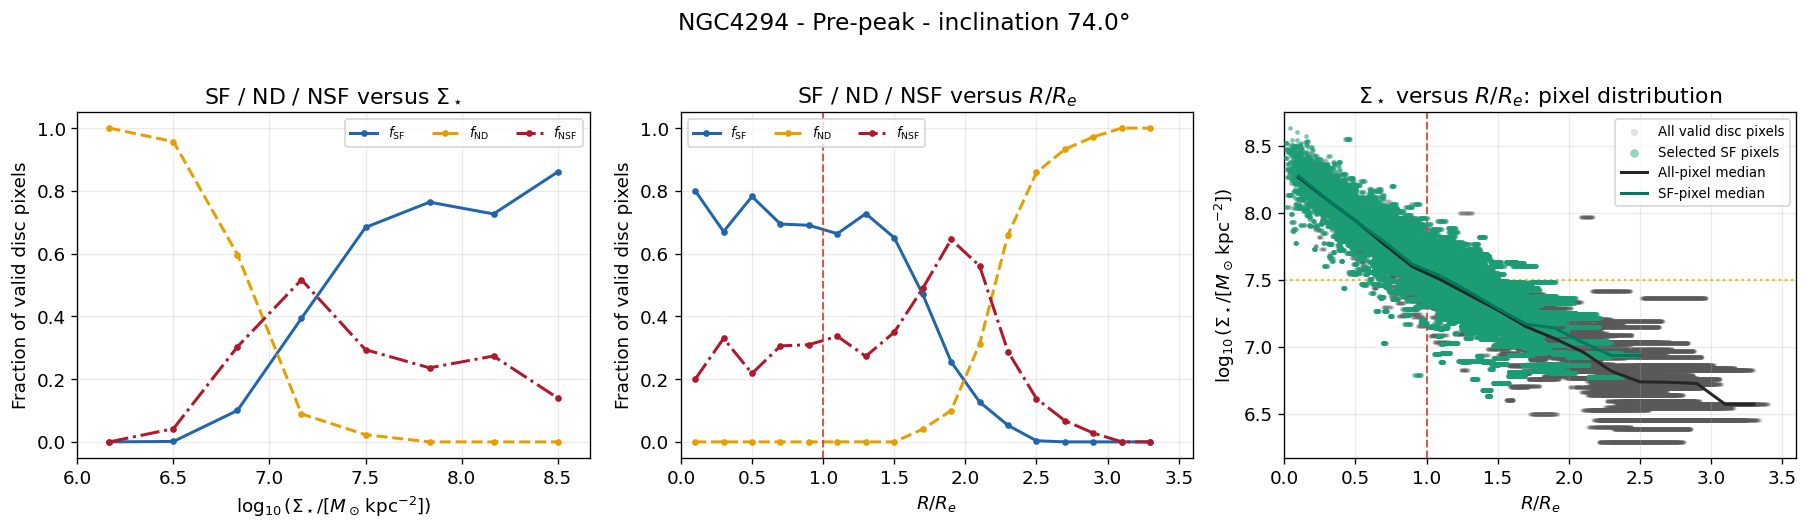

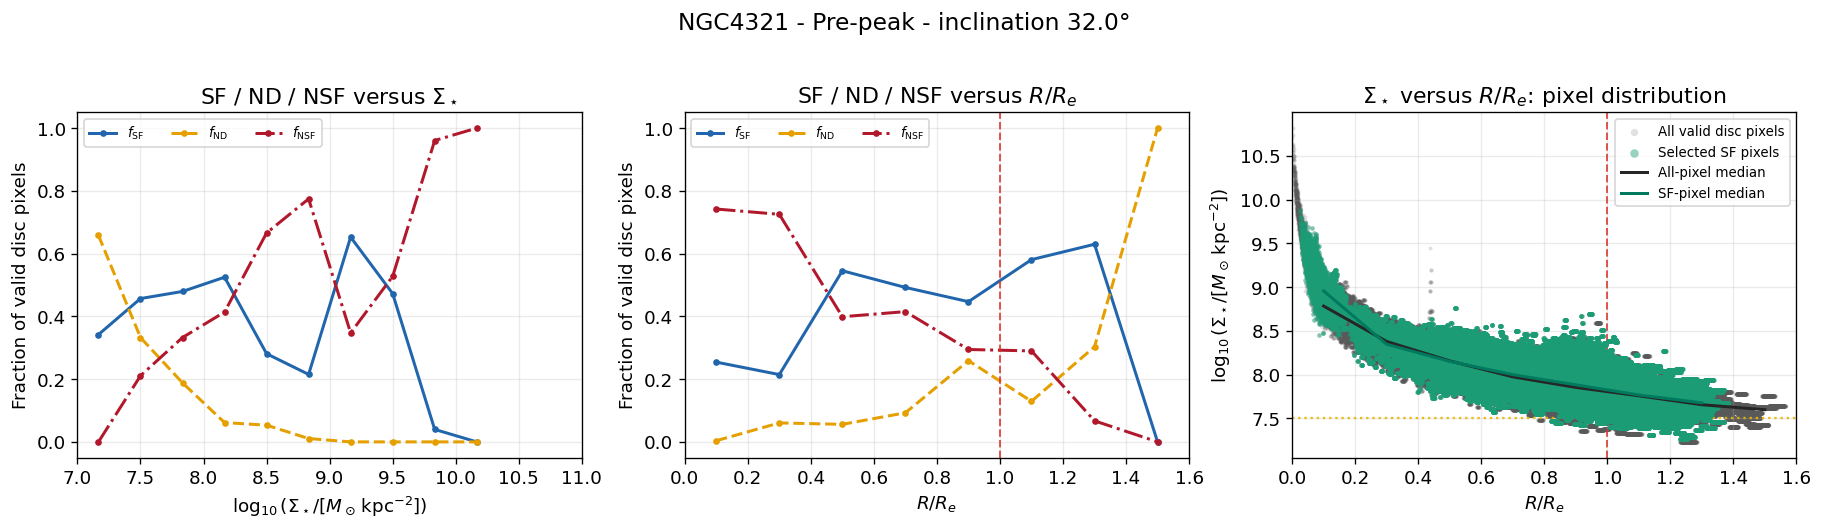

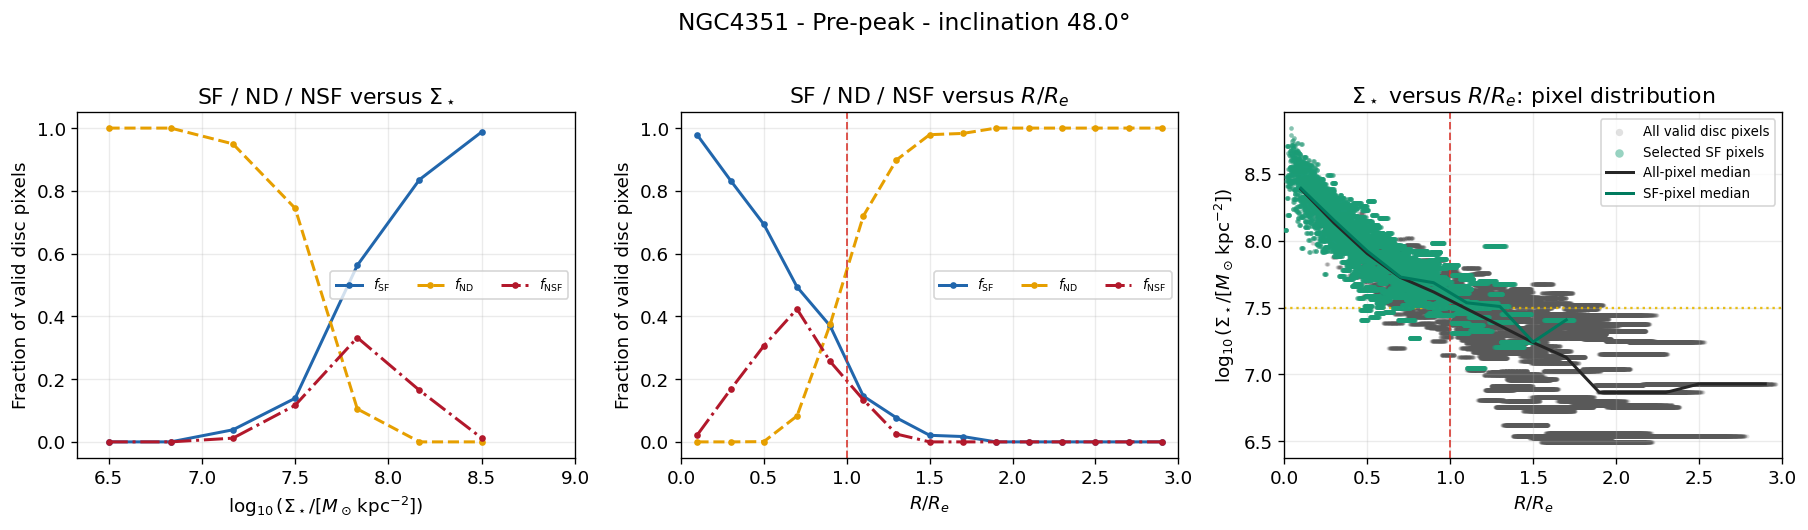

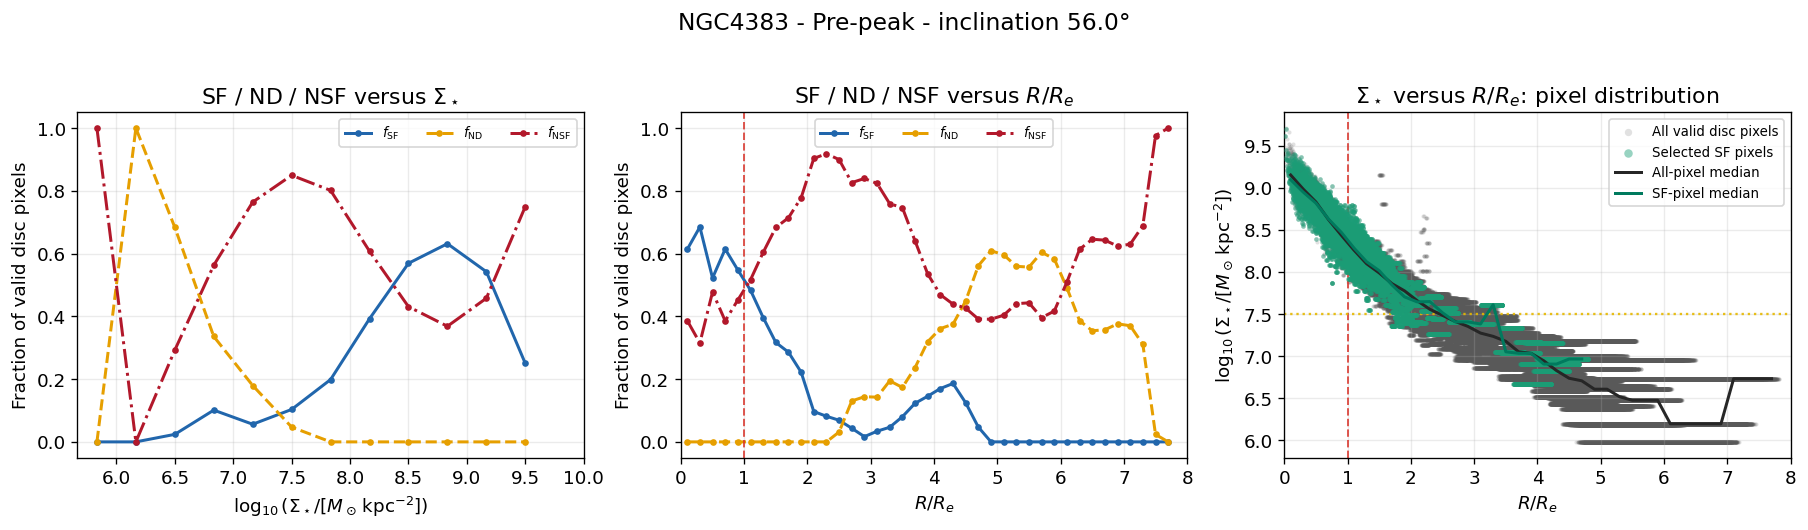

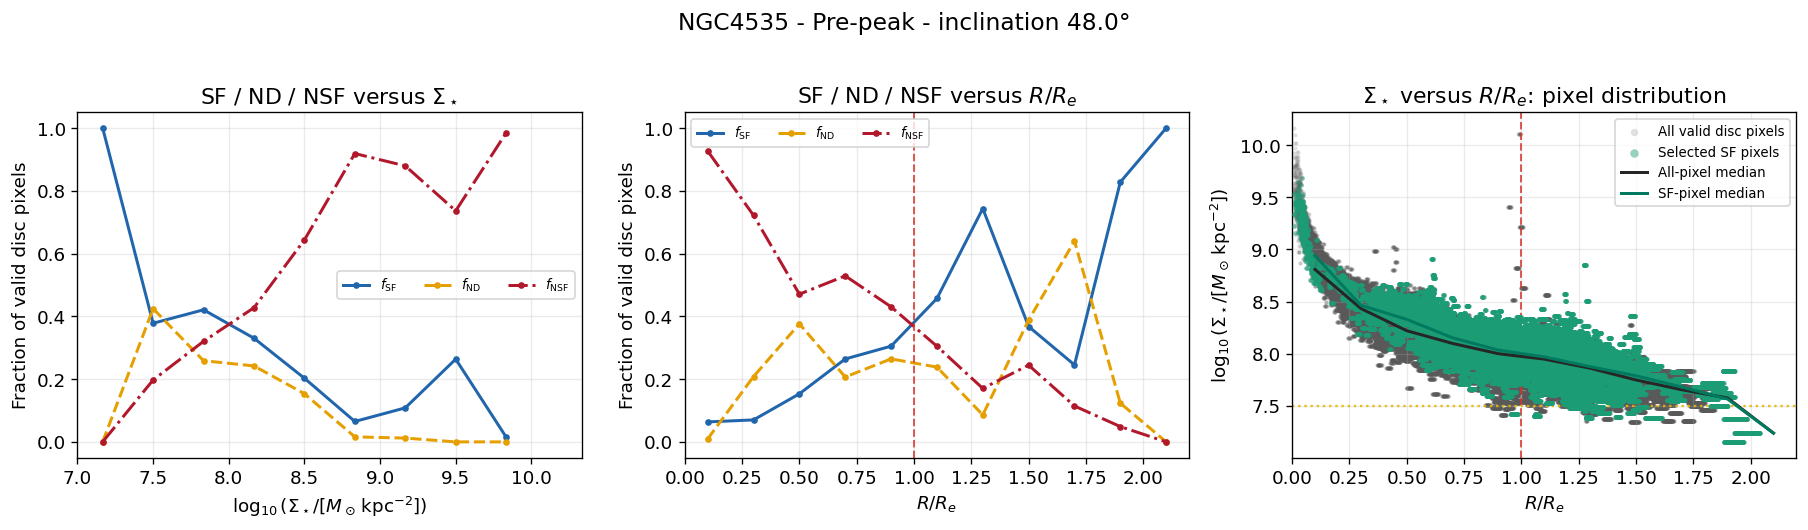

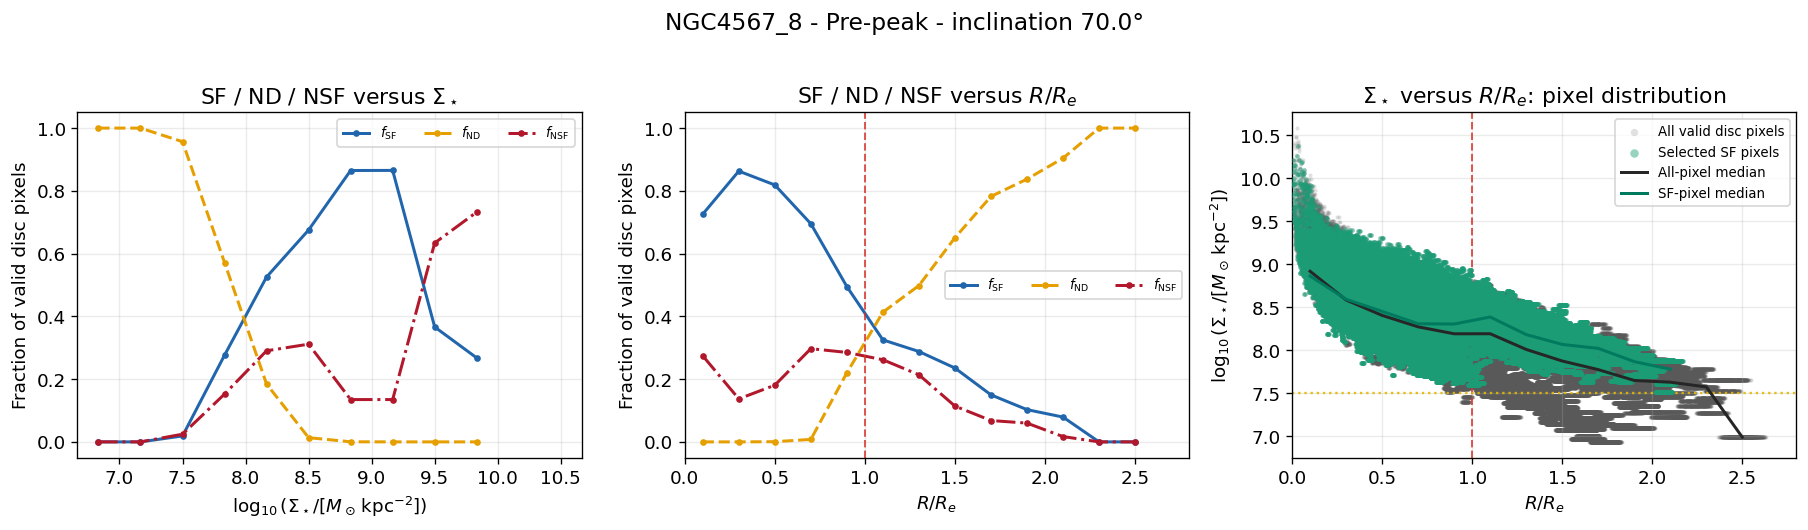

In [5]:
# Recreate the cell 9 diagnostics with the full pixel distributions in panel 3.
for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    measurements = individual_measurements[row.GALID]
    by_sigma = measurements["fSF_by_sigma"]
    by_radius = measurements["fSF_by_radius"]
    mass_by_radius = measurements["mass_by_radius"]
    galaxy_sigma_edges = measurements["sigma_edges"]
    galaxy_radius_edges = measurements["radius_edges"]

    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.3))
    fig.suptitle(
        f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f}°",
        fontsize=14, y=1.02,
    )

    plot_category_fractions(axes[0], by_sigma)
    axes[0].set(
        xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $\Sigma_\star$",
        xlim=(galaxy_sigma_edges[0], galaxy_sigma_edges[-1]), ylim=(-0.05, 1.05),
    )
    plot_category_fractions(axes[1], by_radius)
    axes[1].set(
        xlabel=r"$R/R_e$", ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)

    all_pixels = maps["valid_disc_mask"]
    sf_pixels = maps["sf_mask"]
    axes[2].scatter(
        maps["radius_re"][all_pixels], maps["log_sigma_star"][all_pixels],
        s=6, color="0.35", alpha=0.18, linewidths=0, rasterized=True, zorder=1,
        label="All valid disc pixels",
    )
    axes[2].scatter(
        maps["radius_re"][sf_pixels], maps["log_sigma_star"][sf_pixels],
        s=8, color="#1b9e77", alpha=0.45, linewidths=0, rasterized=True, zorder=3,
        label="Selected SF pixels",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.all_median,
        lw=1.8, color="0.15", zorder=4, label="All-pixel median",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.sf_median,
        lw=1.8, color="#007a5e", zorder=5, label="SF-pixel median",
    )
    axes[2].set(
        xlabel=r"$R/R_e$",
        ylabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        title=r"$\Sigma_\star$ versus $R/R_e$: pixel distribution",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]),
    )
    axes[2].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8, zorder=2)
    axes[2].axhline(
        MASS_CONTOUR_LEVEL, color="#e6b800", ls=":", lw=1.4, alpha=0.9, zorder=2
    )
    axes[2].legend(fontsize=8, markerscale=1.8)

    for axis in axes:
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

## 5. Pre-peak stellar-mass maps with $R_e$ and $\log\Sigma_\star=7.5$ boundaries

The map styling follows cell 7 of the 2026-08-20 source notebook: grayscale stellar mass, the selected H II-region SFR overlay, and a red $R_e$ boundary. The new yellow contour marks the boundary at $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])=7.5$.

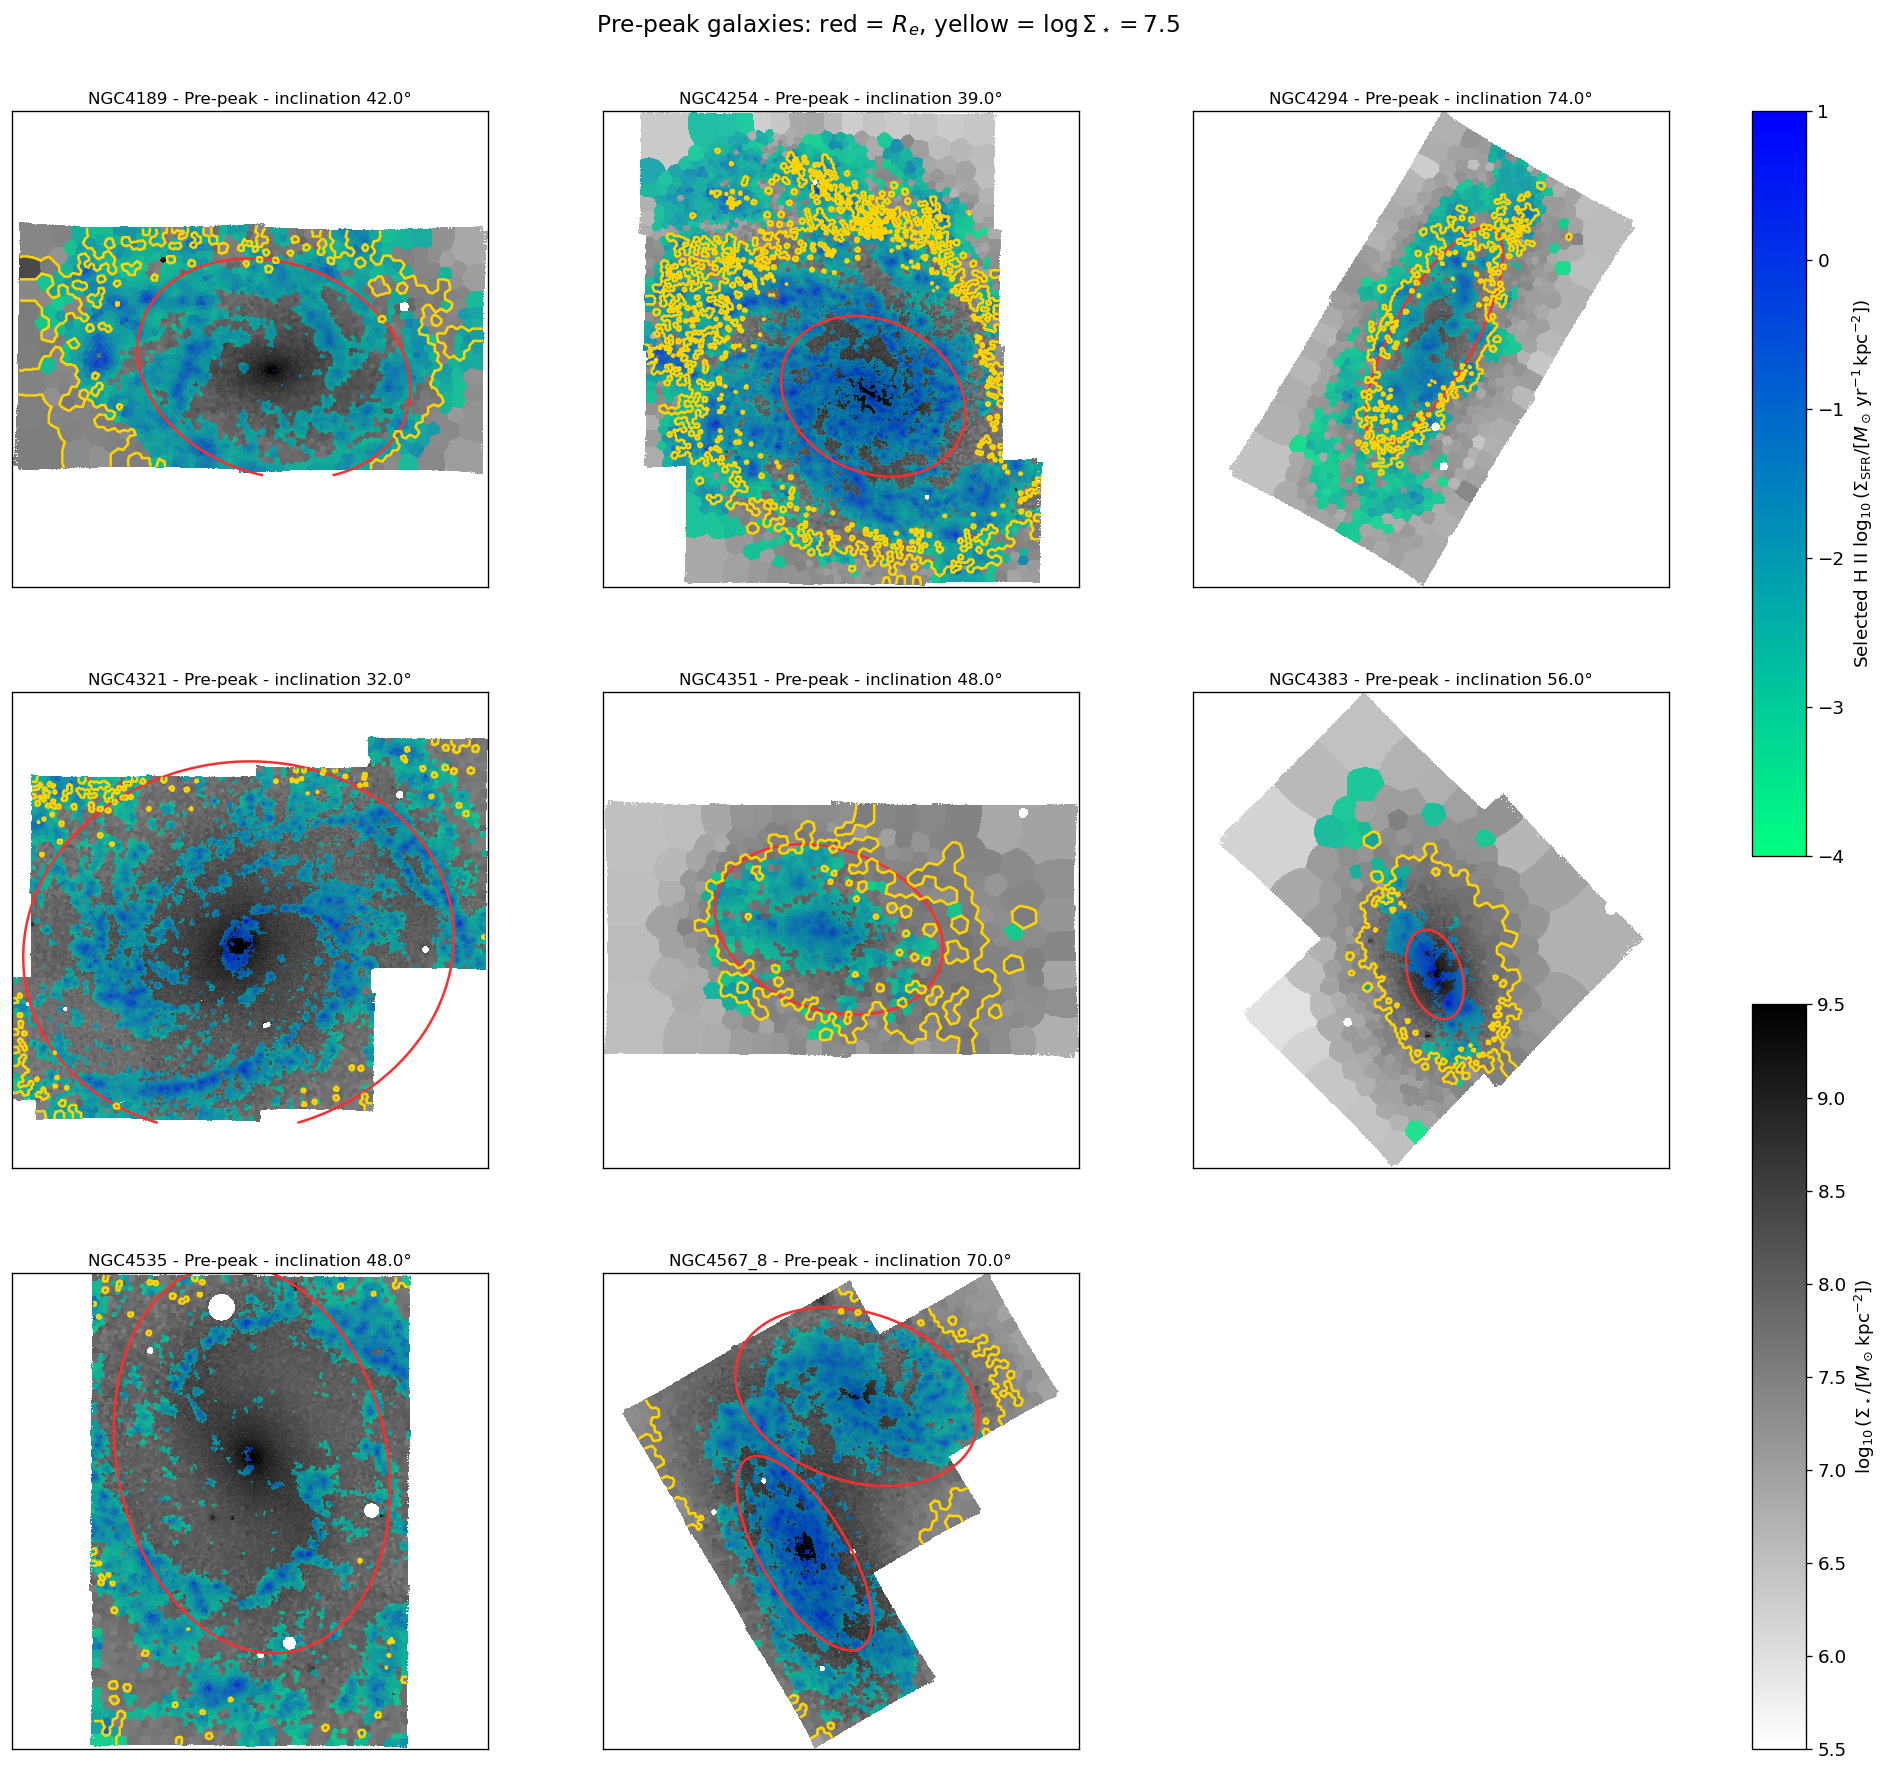

,GALID,inclination_deg,N_valid_pixels,N_selected_SF_pixels,N_finite_mass_pixels_ge_7p5,Re_boundary_drawn,logSigmaStar_7p5_boundary_drawn
0,NGC4189,42.0,177204,96364,130272,True,True
1,NGC4254,39.0,1043477,661963,592173,True,True
2,NGC4294,74.0,179355,68833,37438,True,True
3,NGC4321,32.0,970159,454131,949452,True,True
4,NGC4351,48.0,180133,30711,62947,True,True
5,NGC4383,56.0,227031,25212,53129,True,True
6,NGC4535,48.0,525101,187113,518545,True,True
7,NGC4567_8,70.0,510118,222533,457194,True,True


In [6]:
ncols = min(3, len(prepeak))
nrows = math.ceil(len(prepeak) / ncols)

# Match the reference notebook: maps occupy the main grid and the two vertical
# colorbars share a narrow right-hand column, with SFR above stellar mass.
fig = plt.figure(figsize=(5.1 * ncols + 0.8, 5.0 * nrows), constrained_layout=False)
map_grid = fig.add_gridspec(
    nrows, ncols + 1, width_ratios=[1] * ncols + [0.10]
)
axes = np.asarray([
    [fig.add_subplot(map_grid[row_index, column_index]) for column_index in range(ncols)]
    for row_index in range(nrows)
])
colorbar_grid = map_grid[:, ncols].subgridspec(2, 1, hspace=0.20)
sfr_colorbar_axis = fig.add_subplot(colorbar_grid[0, 0])
mass_colorbar_axis = fig.add_subplot(colorbar_grid[1, 0])

mass_norm = mpl.colors.Normalize(vmin=5.5, vmax=9.5)
sfr_norm = mpl.colors.Normalize(vmin=-4.0, vmax=1.0)
sfr_cmap = mpl.colormaps["winter_r"].copy()
sfr_cmap.set_bad((0.0, 0.0, 0.0, 0.0))

map_audit_rows = []
for axis, row in zip(axes.ravel(), prepeak.itertuples(index=False)):
    maps = map_cache[row.GALID]
    mass = maps["log_sigma_star"]
    radius = maps["radius_re"]
    sfr_overlay = np.ma.masked_where(~maps["sf_mask"], maps["log_sigma_sfr"])

    axis.imshow(mass, origin="lower", cmap="gray_r", norm=mass_norm, interpolation="nearest")
    axis.imshow(
        sfr_overlay, origin="lower", cmap=sfr_cmap, norm=sfr_norm,
        interpolation="nearest", alpha=0.82,
    )
    re_contour = axis.contour(
        radius, levels=[1.0], colors="#ff2d2d", linewidths=1.5, origin="lower"
    )
    sigma_contour = axis.contour(
        mass, levels=[MASS_CONTOUR_LEVEL], colors="#ffd400", linewidths=1.5, origin="lower"
    )
    axis.set_title(
        f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f}°",
        fontsize=10, pad=4,
    )
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_box_aspect(1)
    map_audit_rows.append({
        "GALID": row.GALID,
        "inclination_deg": row.inclination,
        "N_valid_pixels": int(maps["valid_disc_mask"].sum()),
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()),
        "N_finite_mass_pixels_ge_7p5": int((np.isfinite(mass) & (mass >= MASS_CONTOUR_LEVEL)).sum()),
        "Re_boundary_drawn": bool(len(re_contour.allsegs[0]) > 0),
        "logSigmaStar_7p5_boundary_drawn": bool(len(sigma_contour.allsegs[0]) > 0),
    })

for axis in axes.ravel()[len(prepeak):]:
    axis.axis("off")

mass_sm = mpl.cm.ScalarMappable(norm=mass_norm, cmap="gray_r")
sfr_sm = mpl.cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sfr_cbar = fig.colorbar(sfr_sm, cax=sfr_colorbar_axis)
sfr_cbar.set_label(
    r"Selected H II $\log_{10}(\Sigma_{\rm SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$"
)
mass_cbar = fig.colorbar(mass_sm, cax=mass_colorbar_axis)
mass_cbar.set_label(r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$")

fig.suptitle(
    r"Pre-peak galaxies: red = $R_e$, yellow = $\log\Sigma_\star=7.5$",
    fontsize=14, y=0.995,
)
fig.subplots_adjust(left=0.03, right=0.975, bottom=0.03, top=0.94, wspace=0.12, hspace=0.22)
PREPEAK_MAP_AUDIT = pd.DataFrame(map_audit_rows)
plt.show()
display(PREPEAK_MAP_AUDIT)

## 6. Why does selection fail?

The next table and stacked bars give one row per pre-peak product, without pooling
pixels across galaxies. They describe the full valid footprint (the profile bins
also span its full range). No independent-spaxel errors or environmental significance
are inferred; pixels share the PSF and may share fitted bins.

ND is based only on Halpha/Hbeta detection. Its invalid-measurement and
measured-below-cut counts partition the orange category, using only those two lines.
SF and NSF together partition the pixels with **both Balmer lines detected**.
All three fractions retain the original valid-disc denominator. There is no
additional detected-SF fraction or conditional-SF curve.


,GALID,N_valid,N_SF,N_ND,N_NSF,f_SF,f_ND,f_NSF,N_ND_invalid_measurement,N_ND_measured_below_cut
0,NGC4189,177204,96364,45185,35655,0.5438,0.2550,0.2012,0,45185
1,NGC4254,1043477,661963,179988,201526,0.6344,0.1725,0.1931,0,179988
2,NGC4294,179355,68833,51275,59247,0.3838,0.2859,0.3303,0,51275
3,NGC4321,970159,454131,141086,374942,0.4681,0.1454,0.3865,0,141086
4,NGC4351,180133,30711,132740,16682,0.1705,0.7369,0.0926,0,132740
5,NGC4383,227031,25212,65261,136558,0.1111,0.2875,0.6015,0,65261
6,NGC4535,525101,187113,130687,207301,0.3563,0.2489,0.3948,0,130687
7,NGC4567_8,510118,222533,185310,102275,0.4362,0.3633,0.2005,0,185310


,GALID,gas_path,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW
0,NGC4189,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
1,NGC4254,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
2,NGC4294,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
3,NGC4321,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
4,NGC4351,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
5,NGC4383,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
6,NGC4535,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
7,NGC4567_8,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti


reason,BPT: stable non-HII,BPT: weak/ambiguous/unavailable,Dispersion >= 45,Dispersion unavailable,EW <= 6,EW unavailable,HII SFR unavailable
GALID,,,,,,,
NGC4189,8684,22995,1342,0,2634,0,0
NGC4254,78727,100760,18634,0,3405,0,0
NGC4294,30880,27993,374,0,0,0,0
NGC4321,123127,216052,10918,0,24845,0,0
NGC4351,5296,11157,99,0,130,0,0
NGC4383,23789,25041,87521,0,207,0,0
NGC4535,45764,140664,2935,0,17938,0,0
NGC4567_8,37739,53471,1324,0,9741,0,0


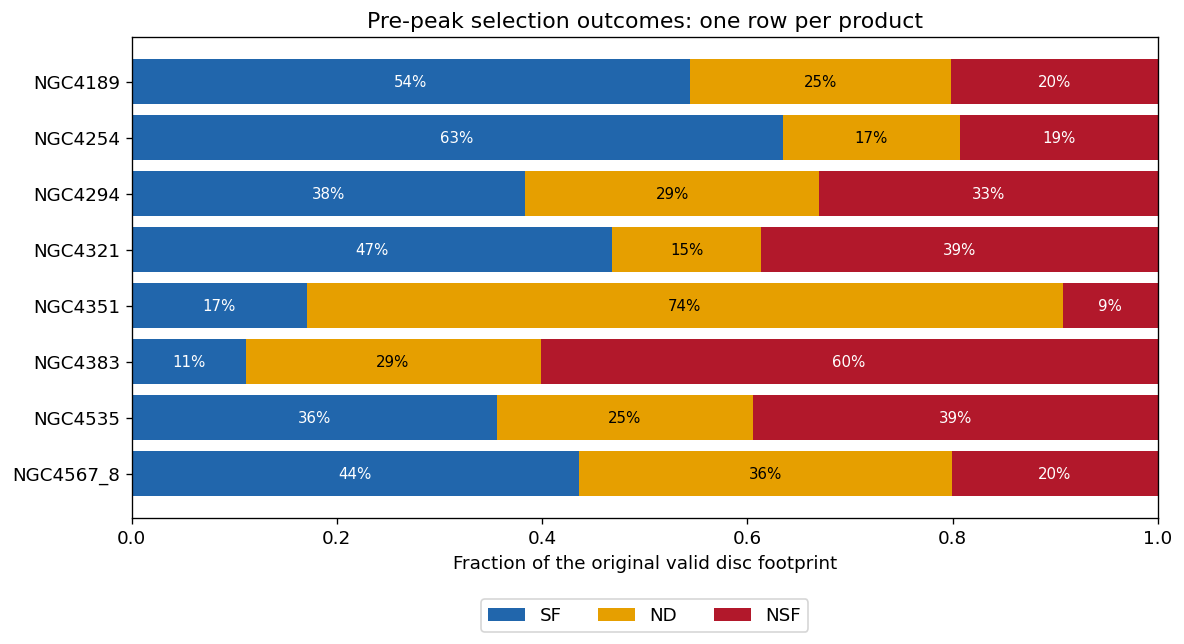

In [7]:

summary_rows, provenance_rows, reason_rows = [], [], []
for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    n = int(maps["valid_disc_mask"].sum())
    counts = {label: int(maps[key].sum()) for label, key in
              (("SF", "sf_mask"), ("ND", "nd_mask"), ("NSF", "nsf_mask"))}
    n_balmer = int((maps["valid_disc_mask"] & maps["balmer_detected_mask"]).sum())
    assert counts["SF"] + counts["NSF"] == n_balmer
    summary_rows.append({
        "GALID": row.GALID, "N_valid": n,
        **{"N_" + key: value for key, value in counts.items()},
        **{"f_" + key: counts[key] / n for key in ("SF", "ND", "NSF")},
        "N_ND_invalid_measurement": int(maps["nd_invalid_mask"].sum()),
        "N_ND_measured_below_cut": int(maps["nd_measured_below_cut_mask"].sum()),
    })
    provenance_rows.append({"GALID": row.GALID, "gas_path": str(row.sfr_path),
                            **maps["detection_provenance"]})
    for label, mask in maps["nsf_reasons"].items():
        reason_rows.append({"GALID": row.GALID, "reason": label, "N_pixels": int(mask.sum()),
                            "fraction_of_valid": mask.sum() / n})
CATEGORY_SUMMARY = pd.DataFrame(summary_rows)
DETECTION_PROVENANCE = pd.DataFrame(provenance_rows)
NSF_REASON_COUNTS = pd.DataFrame(reason_rows)
display(CATEGORY_SUMMARY.round(4))
display(DETECTION_PROVENANCE)
display(NSF_REASON_COUNTS.pivot(index="GALID", columns="reason", values="N_pixels"))

fig, ax = plt.subplots(figsize=(10, 0.48 * len(prepeak) + 1.7))
left = np.zeros(len(prepeak))
for label in ("SF", "ND", "NSF"):
    vals = CATEGORY_SUMMARY["f_" + label].to_numpy()
    ax.barh(CATEGORY_SUMMARY.GALID, vals, left=left, color=CATEGORY_COLORS[label], label=label)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v >= 0.045:
            ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=9,
                    color="black" if label == "ND" else "white")
    left += vals
ax.set(xlim=(0, 1), xlabel="Fraction of the original valid disc footprint",
       title="Pre-peak selection outcomes: one row per product")
ax.invert_yaxis()
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15))
fig.tight_layout()
plt.show()


### Spatial categories, Balmer failures, and NSF rejection gates

Each galaxy has three additional panels:

1. A categorical map of the **same valid footprint**, with white outside it.
   Red and yellow contours retain $R_e$ and $\log\Sigma_\star=7.5$.
2. For Halpha and Hbeta separately, the fraction of valid pixels failing that
   line's detection cut, versus radius. The two curves overlap where both fail;
   their union is the black dashed $f_{\rm ND}$ curve.
3. An exclusive breakdown of NSF (both Balmer lines detected), versus radius,
   evaluated in order: unavailable H II SFR (split into stable non-HII BPT,
   weak/ambiguous/unavailable BPT, or both class maps HII but SFR unavailable),
   then missing EW, EW<=6, missing intrinsic dispersion, dispersion>=45.
   These curves sum to the black dashed $f_{\rm NSF}$. Earlier failures take
   priority when cuts overlap.

Stable non-HII means at least one independent BPT class map has code 2 or 3.
The weak/ambiguous/unavailable group includes code 0/-1 when no stable non-HII
diagnostic has already identified the pixel. In particular, **forbidden-line
non-detections can fall within NSF rather than ND**. This group is not a secure
non-HII classification. The independent BPT maps are stricter than `_HII`
selection and are used here only to describe pixels without finite H II SFR.

The inherited intrinsic-dispersion calculation returns NaN when
$\sigma_{\rm obs}^2-\sigma_{\rm corr}^2\le0$; such unresolved/invalid measurements
belong to **dispersion unavailable**, not the high-dispersion group. No original
SF selection is repaired or relaxed here. All profile denominators remain the
valid disc pixels in the bin, with the same 50-pixel minimum. First-failed gates
are bookkeeping, not evidence of a unique physical mechanism.


<ipython-input-1-050713c9fdcb>:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.2))


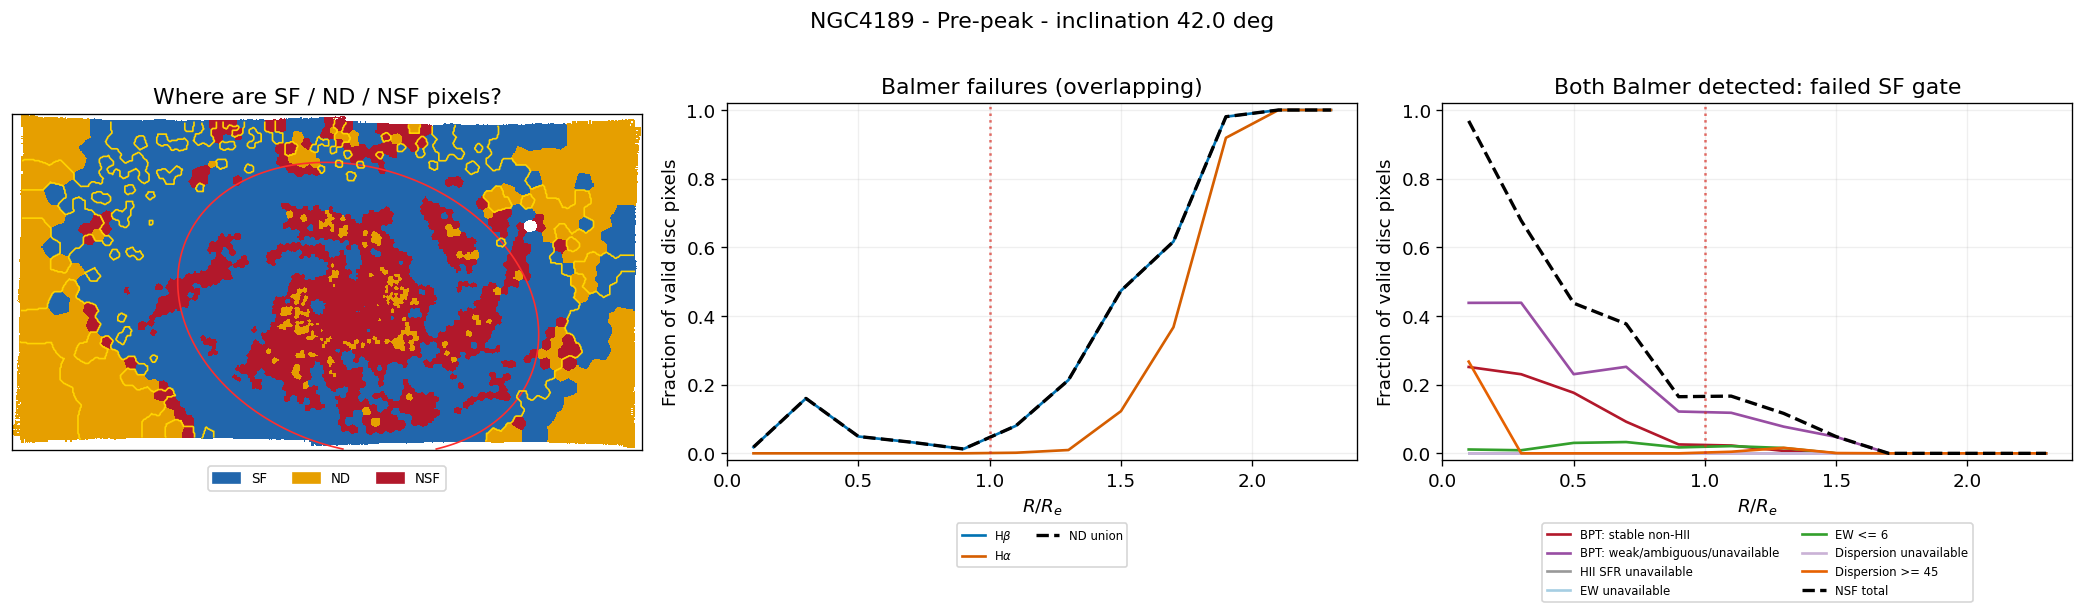

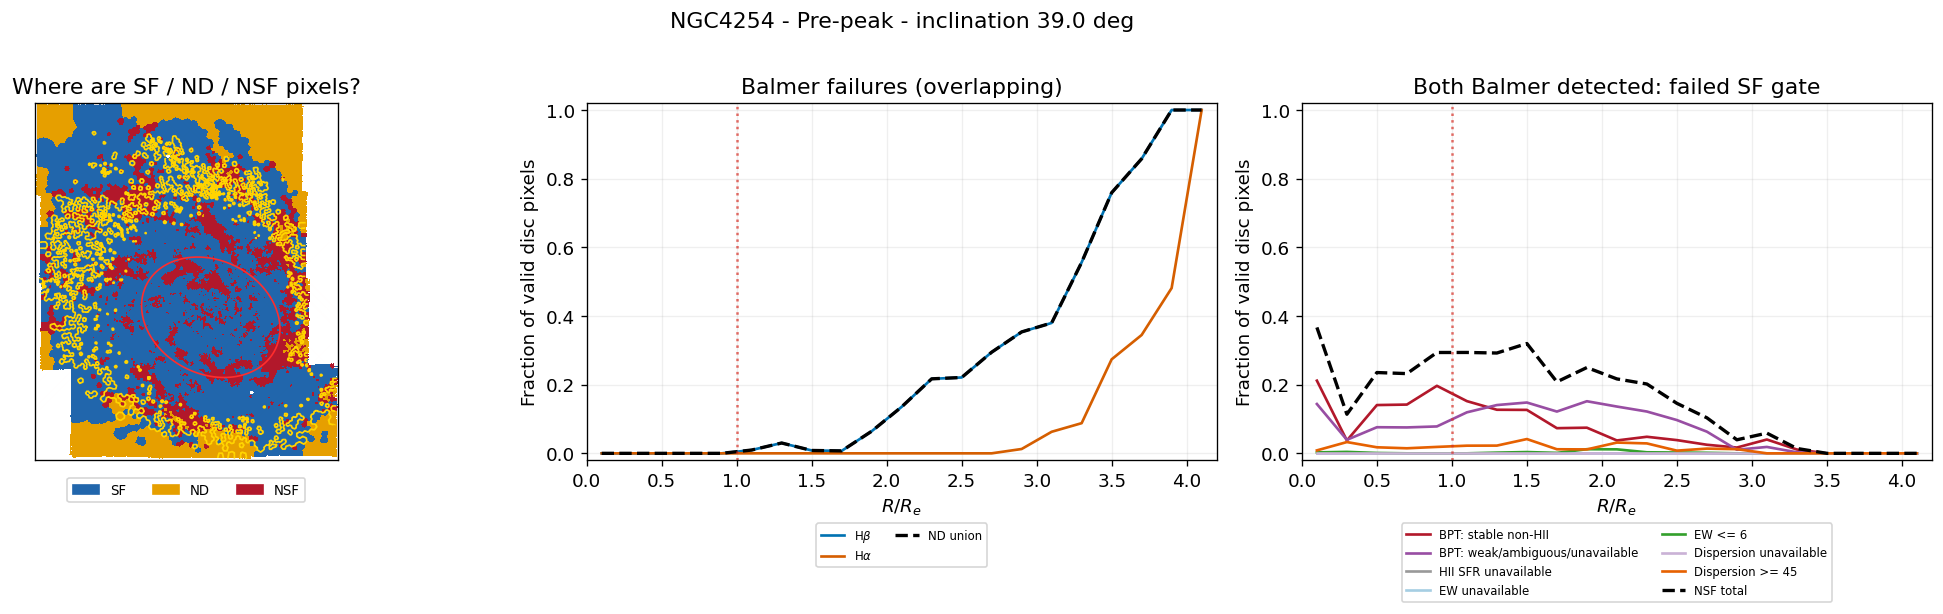

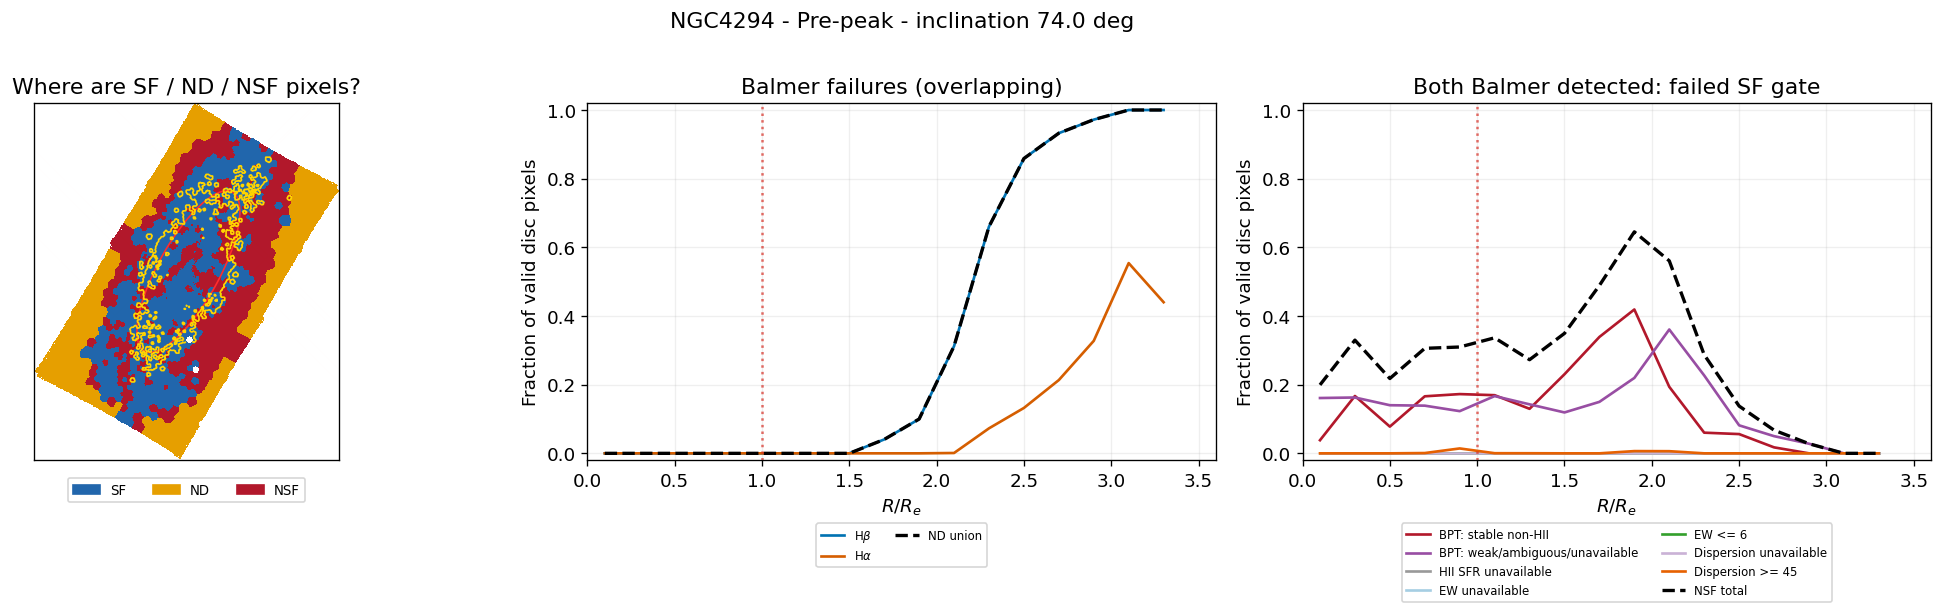

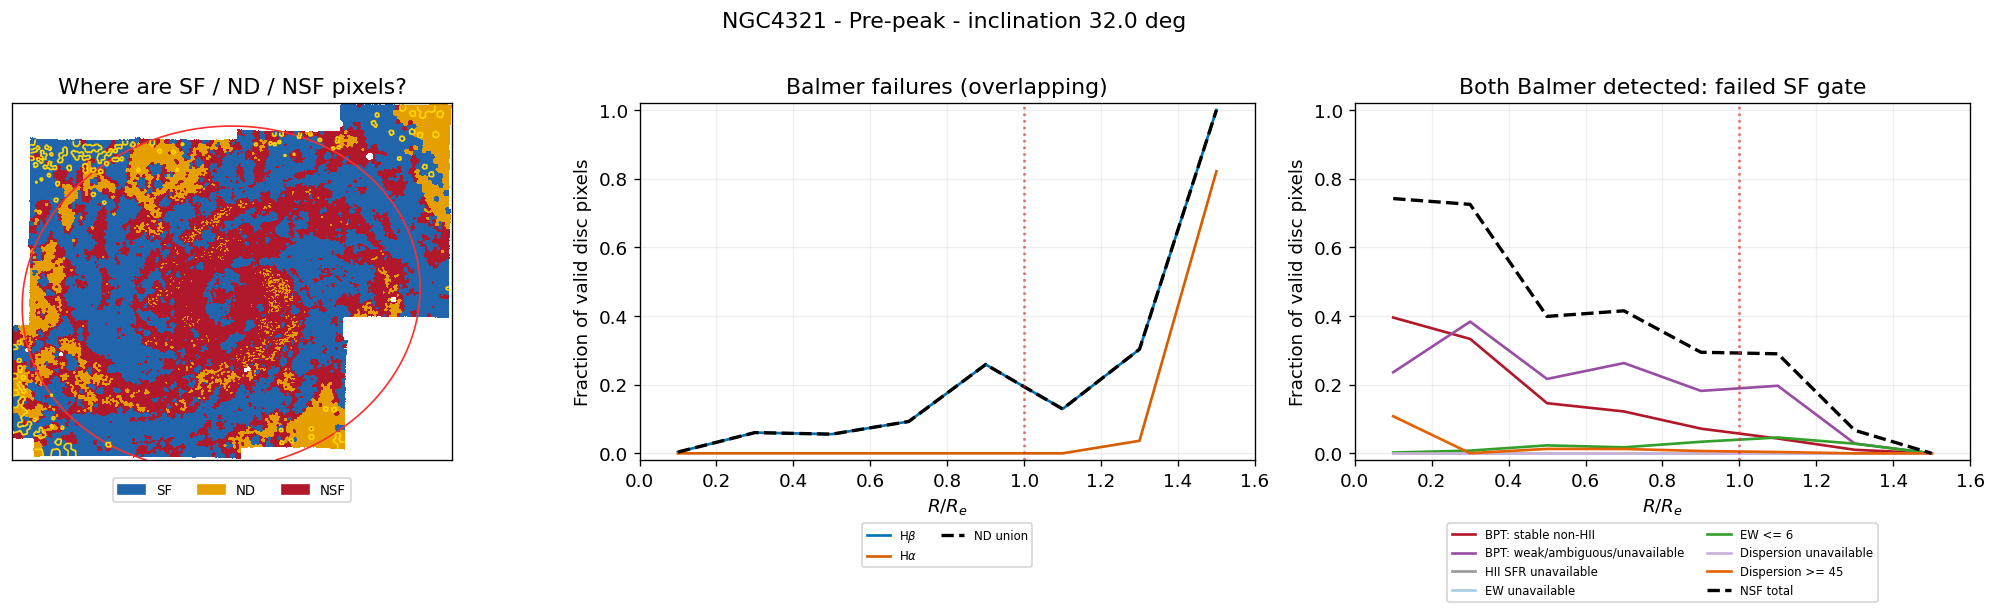

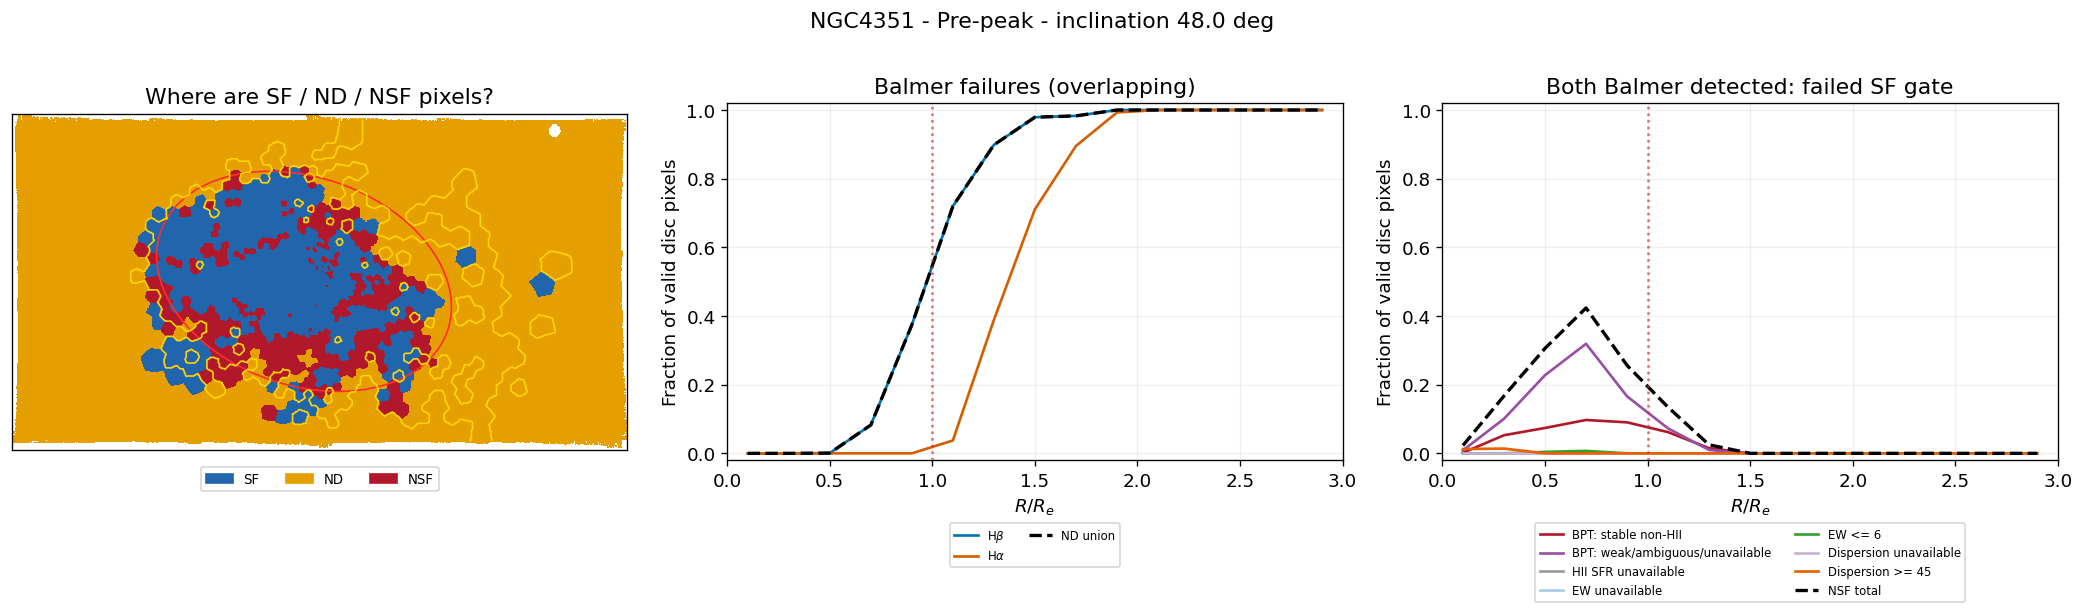

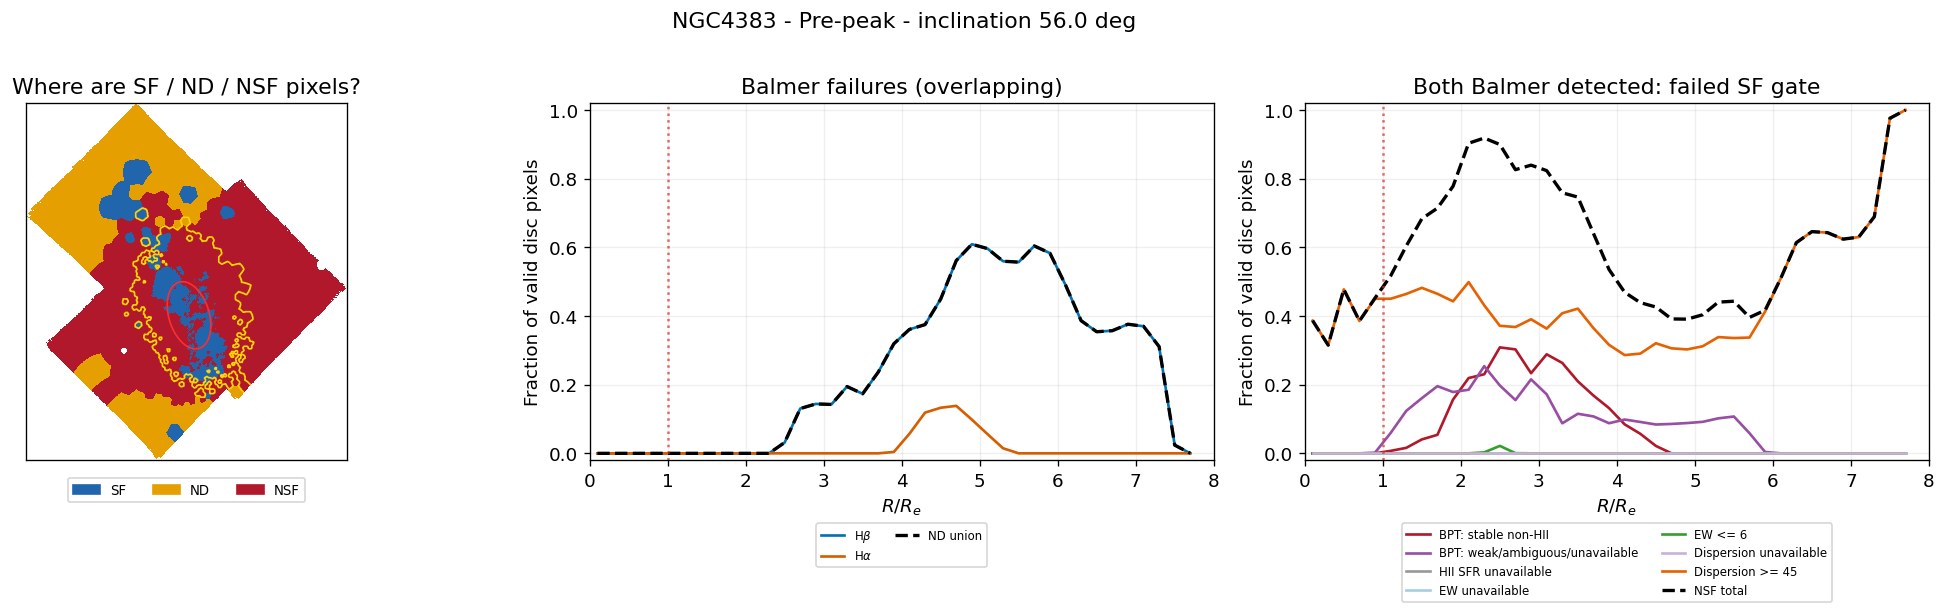

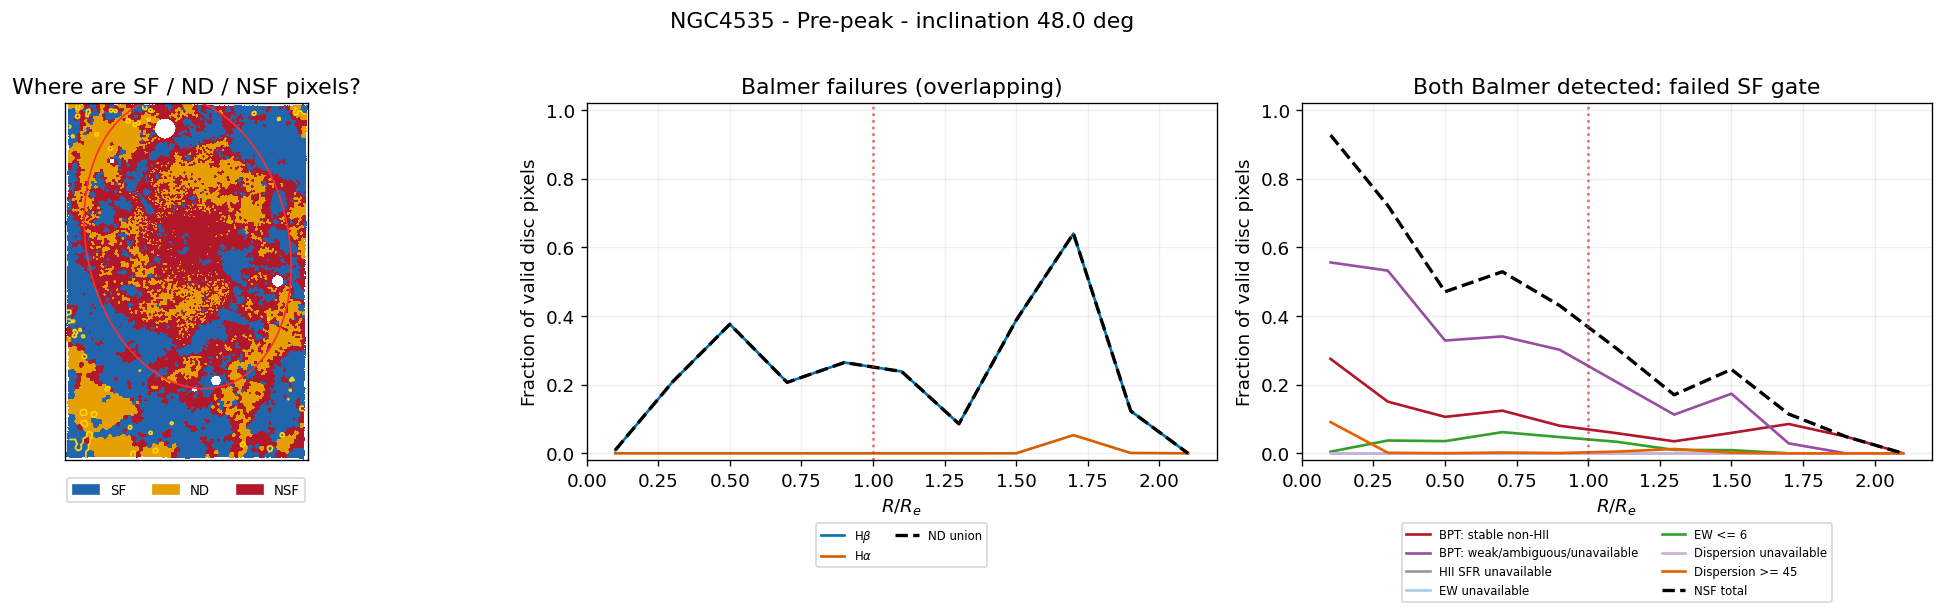

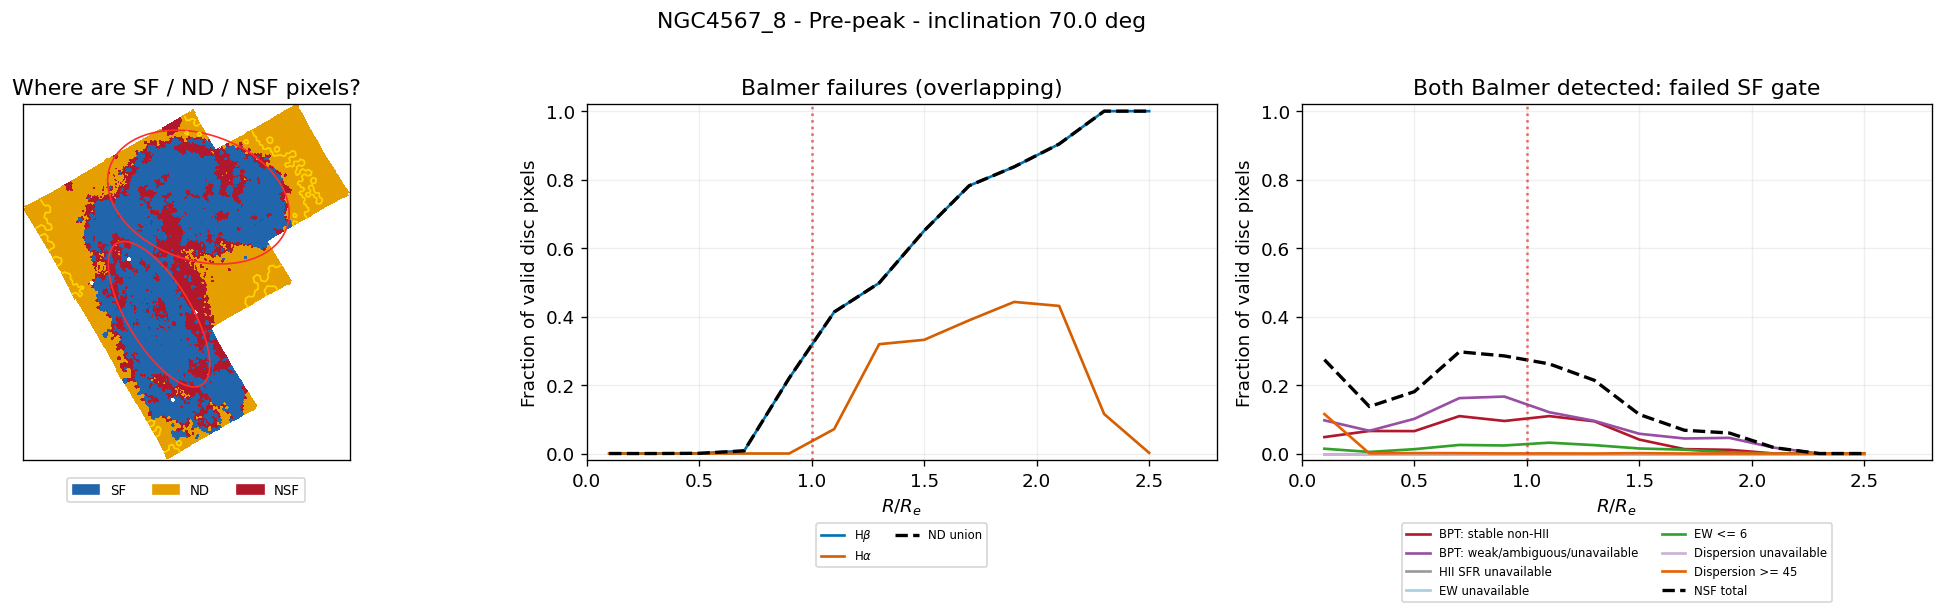

In [8]:

REASON_PROFILES = {}
for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    measurement = individual_measurements[row.GALID]
    edges = measurement["radius_edges"]
    total = measurement["fSF_by_radius"]
    fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.2))
    fig.suptitle(f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f} deg", y=1.01)
    category = np.full(maps["valid_disc_mask"].shape, np.nan)
    for code, key in enumerate(("sf_mask", "nd_mask", "nsf_mask")):
        category[maps[key]] = code
    cmap = mpl.colors.ListedColormap([CATEGORY_COLORS[k] for k in ("SF", "ND", "NSF")])
    cmap.set_bad("white")
    axes[0].imshow(np.ma.masked_invalid(category), origin="lower", cmap=cmap,
                   vmin=-0.5, vmax=2.5, interpolation="nearest")
    axes[0].contour(maps["radius_re"], levels=[1], colors="#ff2d2d", linewidths=1.0)
    axes[0].contour(maps["log_sigma_star"], levels=[MASS_CONTOUR_LEVEL],
                    colors="#ffd400", linewidths=1.0)
    axes[0].set(title="Where are SF / ND / NSF pixels?", xticks=[], yticks=[])
    axes[0].legend(handles=[mpl.patches.Patch(color=CATEGORY_COLORS[k], label=k)
                            for k in ("SF", "ND", "NSF")],
                   loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, fontsize=8)
    line_profiles, reason_profiles = {}, {}
    line_colors = ("#0072b2", "#d55e00")
    for line, label, color in zip(BALMER_LINES, LINE_LABELS, line_colors):
        mask = maps["valid_disc_mask"] & ~maps["line_detected"][line]
        tab = binned_fraction(maps["radius_re"], maps["valid_disc_mask"], mask, edges)
        line_profiles[line] = tab.rename(columns={"N_SF": "N_failed", "f_SF": "f_failed"})
        axes[1].plot(tab.center, tab.f_SF, color=color, label=label, lw=1.6)
    axes[1].plot(total.center, total.f_ND, "k--", lw=2, label="ND union")
    axes[1].set(title="Balmer failures (overlapping)")
    for label, color in zip(REASON_LABELS, REASON_COLORS):
        tab = binned_fraction(maps["radius_re"], maps["valid_disc_mask"],
                              maps["nsf_reasons"][label], edges)
        reason_profiles[label] = tab.rename(columns={"N_SF": "N_reason", "f_SF": "f_reason"})
        axes[2].plot(tab.center, tab.f_SF, color=color, label=label, lw=1.6)
    reason_sum = sum(tab.N_reason.to_numpy() for tab in reason_profiles.values())
    assert np.array_equal(reason_sum, total.N_NSF.to_numpy())
    axes[2].plot(total.center, total.f_NSF, "k--", lw=2, label="NSF total")
    axes[2].set(title="Both Balmer detected: failed SF gate")
    REASON_PROFILES[row.GALID] = {"line_failures": line_profiles, "NSF_reasons": reason_profiles}
    for ax in axes[1:]:
        ax.set(xlabel=r"$R/R_e$", ylabel="Fraction of valid disc pixels",
               xlim=(edges[0], edges[-1]), ylim=(-0.02, 1.02))
        ax.axvline(1, color="#d73027", ls=":", alpha=0.7)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
    fig.tight_layout()
    plt.show()


In [9]:
# Regenerate this concise reading from the current tables on every run.
n_nd_larger = int((CATEGORY_SUMMARY.f_ND > CATEGORY_SUMMARY.f_NSF).sum())
print(f"Balmer ND exceeds NSF in {n_nd_larger}/{len(CATEGORY_SUMMARY)} product footprints.")
for column, label in (("f_ND", "ND"), ("f_NSF", "NSF (both Balmer detected)")):
    row = CATEGORY_SUMMARY.loc[CATEGORY_SUMMARY[column].idxmax()]
    print(f"Largest {label} fraction: {row.GALID}; "
          f"SF={row.f_SF:.1%}, ND={row.f_ND:.1%}, NSF={row.f_NSF:.1%} of valid pixels.")
print("Verified: every original SF pixel has both Balmer lines detected.")
print(f"ND pixels with unavailable/invalid Balmer measurements: "
      f"{CATEGORY_SUMMARY.N_ND_invalid_measurement.sum():,}; "
      "other ND pixels have measured Balmer flux/error but fail at least one Balmer detection cut.")
dominant = NSF_REASON_COUNTS.loc[
    NSF_REASON_COUNTS.groupby("GALID").N_pixels.idxmax()
].copy()
dominant = dominant.merge(CATEGORY_SUMMARY[["GALID", "N_NSF"]], on="GALID", validate="one_to_one")
dominant["fraction_of_NSF"] = dominant.N_pixels / dominant.N_NSF.replace(0, np.nan)
print("Largest first-failed gate within each product's NSF category (both Balmer detected):")
display(dominant[["GALID", "reason", "N_pixels", "fraction_of_valid", "fraction_of_NSF"]].round(4))
print("These are descriptive selection outcomes within the observed valid footprint; "
      "they do not establish a physical cause or prove that star formation is absent.")


Balmer ND exceeds NSF in 3/8 product footprints.
Largest ND fraction: NGC4351; SF=17.0%, ND=73.7%, NSF=9.3% of valid pixels.
Largest NSF (both Balmer detected) fraction: NGC4383; SF=11.1%, ND=28.7%, NSF=60.1% of valid pixels.
Verified: every original SF pixel has both Balmer lines detected.
ND pixels with unavailable/invalid Balmer measurements: 0; other ND pixels have measured Balmer flux/error but fail at least one Balmer detection cut.
Largest first-failed gate within each product's NSF category (both Balmer detected):
These are descriptive selection outcomes within the observed valid footprint; they do not establish a physical cause or prove that star formation is absent.


,GALID,reason,N_pixels,fraction_of_valid,fraction_of_NSF
0,NGC4189,BPT: weak/ambiguous/unavailable,22995,0.1298,0.6449
1,NGC4254,BPT: weak/ambiguous/unavailable,100760,0.0966,0.5000
2,NGC4294,BPT: stable non-HII,30880,0.1722,0.5212
3,NGC4321,BPT: weak/ambiguous/unavailable,216052,0.2227,0.5762
4,NGC4351,BPT: weak/ambiguous/unavailable,11157,0.0619,0.6688
5,NGC4383,Dispersion >= 45,87521,0.3855,0.6409
6,NGC4535,BPT: weak/ambiguous/unavailable,140664,0.2679,0.6785
7,NGC4567_8,BPT: weak/ambiguous/unavailable,53471,0.1048,0.5228


### Reading the result and limits

- Compare orange ND and red NSF at the same stellar density or radius to identify
  whether rejected pixels lack adequate Balmer detections or fail SF selection
  despite both Balmer detections. Use the category map to locate these pixels.
- Use the two Balmer-failure profiles to distinguish failure of Halpha, Hbeta,
  or both. A failed cut can reflect the flux floor rather than low S/N.
- Check the NSF breakdown before interpreting the red curve: weak forbidden
  lines or ambiguous BPT classification, low EW, high dispersion, and unavailable
  measurements are different outcomes. NSF is not proof of absent star formation.
- The blue SF curve is unchanged from 0828. All original selected SF pixels must
  pass both Balmer detection cuts; the code verifies this, rather than defining
  another SF-with-detection fraction. No six-line detection gate is added to SF.

This remains a pre-peak-only, descriptive selection audit. No pipeline/FITS files
are modified and no figures or tables are saved externally by notebook cells.
No close-to-peak/post-peak analysis, pooled inference, or independent-spaxel
significance is added. The original valid footprint and source SF mask remain
the reference, rather than the entire physical galaxy.


### Ensemble-fitting scope

This fraction-only notebook does not fit an ensemble rSFMS, so no galaxy-weighting estimator is applied here. In the standalone and combined rSFMS notebooks, each selected-SF spaxel in galaxy $g$ receives fit weight $w_{ig}=1/N_{\mathrm{SF},g}$, giving every galaxy equal total weight in the ensemble SF-only OLS guide.